# **1. Veri Biliminin Temelleri (Fundamentals of Data Science)**

# İçindekiler

## 1. Veri Seti Hazırlığı
1.1 Veri Seti Hazırlığı

## 2. Eksik Veri (Missing Values) Analizi
2.1. Eksik Verilerin Belirlenmesi  
2.2 Yöntem 1: Eksik Verilerin Silinmesi  
2.3 Yöntem 2: Eksik Verilerin Doldurulması  
- 2.3.1 Sayısal Değişkenlerin Doldurulması  
- 2.3.2 Kategorik Değişkenlerin Doldurulması  
- 2.3.3 Kategorik Kırılım ile Eksik Veri Doldurma  
- 2.3.4 Makine Öğrenmesi ile Eksik Veri Doldurma

## 3. Kategorik Değişken Analizi
3.1 Kategorik Değişken İşlemleri  
3.2 Kategorik Değişkenlerde Görselleştirme İşlemleri  
3.3 Kategorik Gruplama (groupby) İşlemleri

## 4. Sürekli Değişken Analizi
4.1 Sürekli Değişkenlerin İncelenmesi

## 5. Aykırı Değer Analizi (Outliers)
5.1 Aykırı Gözlemlerin Silinmesi  
5.2 Aykırı Gözlemlerin Doldurulması  
- 5.2.1 Ortalama Değer İle Doldurma  
- 5.2.2 Baskılama Yöntemi

## 6. Feature Engineering
6.1 Yeni Özellik Türetme (Feature Creation)  
6.2 One-Hot Encoding  
6.3 Feature Scaling (Ölçekleme)

# Veri Biliminin Temelleri (Fundamentals of Data Science) - Uygulamalı Ders

Bu notebook'ta, **Social Media vs Productivity** dataset’i üzerinde veri hazırlığı sürecinin tüm adımlarını birlikte uygulayacağız. Teoride öğrendiğimiz kavramları, gerçek bir sosyal medya ve verimlilik veri seti üzerinde pratik yaparak pekiştireceğiz.

### Bu Derste Öğrenecekleriniz:
- Eksik veri analizi ve doldurma stratejileri
- Veri tipi problemlerini çözme
- Aykırı değer (outlier) tespiti ve yönetimi
- Kategorik verileri kodlama (ör. sosyal medya platformları, kullanıcı türleri)
- Özellik ölçeklendirme (feature scaling)
- Temiz ve modellemeye hazır veri seti oluşturma

---

## Veri Hazırlığı Neden Kritik?

Data Science projelerinde **zamanın %70-80’i veri hazırlığına** harcanır. Çünkü:

1. **"Garbage In, Garbage Out"** prensibi: Kirli veri → Yanlış sonuçlar
2. Makine öğrenmesi modelleri eksik veya hatalı veriyle çalışamaz
3. Sosyal medya ve verimlilik verileri genellikle eksik, hatalı veya tutarsızdır — gerçek projeler böyledir

**Örnekler:**
- Kullanıcıların sosyal medya kullanım süreleri yanlış veya eksik olabilir (örn. negatif değerler veya aşırı yüksek sayılar)
- Platform isimleri farklı formatlarda olabilir (örn. “Facebook”, “facebook”, “FB”)
- Verimlilik skorları eksik veya hatalı kaydedilmiş olabilir
- Gönderi sayıları, yorum veya beğeni sayıları yanlış olabilir

Tüm bunları düzeltmeden **Social Media vs Productivity** dataset’i ile doğru analiz ve modelleme yapmak mümkün değildir.

**Gerekli Kütüphaneleri Yükleme**

In [1]:
# Temel veri işleme kütüphaneleri
import pandas as pd # Veri manipülasyonu için en önemli araç
import numpy as np # Matematiksel işlemler ve array işlemleri

# Görselleştirme kütüphaneleri
import matplotlib.pyplot as plt # Temel grafik çizimi
import seaborn as sns # Daha güzel ve kolay grafikler

# Uyarıları kapat (temiz görünüm için)
import warnings
warnings.filterwarnings('ignore')

# Grafik ayarları
plt.style.use('seaborn-v0_8-darkgrid') #Matplotlib grafiklerine Seaborn’un koyu grid (ızgara) stilini uygular.
#Grafiklerin arka planı daha okunabilir hale gelir ve eksen çizgileri belirginleşir.
sns.set_palette("husl") #husl paleti, kategorik değişkenlerin daha net ayırt edilmesini sağlayan, dengeli ve kontrastı yüksek renkler üretir.
%matplotlib inline

**1.1 Veri Seti Hazırlığı**

Veri Seti ve Adresi: Social Media vs Productivity Dataset

https://www.kaggle.com/datasets/mahdimashayekhi/social-media-vs-productivity

📊**Dataset Hakkında: Social Media vs Productivity Dataset**

Bireylerin günlük dijital alışkanlıklarının (sosyal medya kullanımı, bildirim sayısı, ekran süresi vb.) üretkenlik, stres seviyesi ve yaşam dengesi üzerindeki etkisini incelemek amacıyla oluşturulmuş davranışsal bir veri setidir.

Bu veri seti, insanların dijital ortamla ne kadar etkileşimde bulunduğunun gerçek ve algılanan üretkenlikleri ile nasıl ilişkilendiğini analiz etmeyi amaçlamaktadır.

Yani dataset şu sorulara cevap arıyor:

“Sosyal medya kullanım alışkanlıkları üretkenliği gerçekten etkiliyor mu?”

Yoksa;

uyku düzeni

çalışma saatleri

gelen bildirim sayısı

ekran süresi

stres seviyesi

gibi faktörler de üretkenlik üzerinde önemli bir rol mü oynuyor?

**Neden bu dataset?**

- ✅ Günlük hayatımızda sıkça karşılaştığımız dijital davranışları analiz ediyor

- ✅ Gerçek veri bilimi projelerine benzer şekilde eksik veriler (missing values) içeriyor

- ✅ Outlier değerler barındırıyor (bildirim sayısı, kahve tüketimi vb.)

- ✅ Hem kategorik hem sayısal değişkenler içeriyor

- ✅ Veri temizleme, veri hazırlama ve feature engineering öğrenmek için ideal

### Veri Setindeki Sütunlar

| No | Sütun Adı                        | Açıklama                                                       |
| -- | -------------------------------- | -------------------------------------------------------------- |
| 1  | `age`                            | Bireyin yaşı (18–65)                                           |
| 2  | `gender`                         | Cinsiyet bilgisi (Male, Female, Other)                         |
| 3  | `job_type`                       | Çalıştığı sektör veya meslek türü (IT, Education, Student vb.) |
| 4  | `daily_social_media_time`        | Günlük sosyal medya kullanım süresi (saat)                     |
| 5  | `social_platform_preference`     | En çok kullanılan sosyal medya platformu                       |
| 6  | `number_of_notifications`        | Günlük alınan mobil/sosyal medya bildirim sayısı               |
| 7  | `work_hours_per_day`             | Günlük ortalama çalışma süresi (saat)                          |
| 8  | `perceived_productivity_score`   | Kişinin kendi üretkenliğini değerlendirdiği skor (0–10)        |
| 9  | `actual_productivity_score`      | Simüle edilmiş gerçek üretkenlik skoru (0–10)                  |
| 10 | `stress_level`                   | Güncel stres seviyesi (1–10)                                   |
| 11 | `sleep_hours`                    | Gecelik ortalama uyku süresi (saat)                            |
| 12 | `screen_time_before_sleep`       | Uyku öncesi ekrana bakma süresi (saat)                         |
| 13 | `breaks_during_work`             | Çalışma sırasında verilen mola sayısı                          |
| 14 | `uses_focus_apps`                | Odaklanma uygulamaları kullanıp kullanmadığı (True / False)    |
| 15 | `has_digital_wellbeing_enabled`  | Digital Wellbeing özelliğinin aktif olup olmadığı              |
| 16 | `coffee_consumption_per_day`     | Günlük tüketilen kahve sayısı                                  |
| 17 | `days_feeling_burnout_per_month` | Aylık tükenmişlik hissedilen gün sayısı                        |
| 18 | `weekly_offline_hours`           | Haftalık çevrimdışı geçirilen toplam süre (saat)               |
| 19 | `job_satisfaction_score`         | İş veya yaşam memnuniyeti skoru (0–10)                         |


In [2]:
!pip install -q kagglehub[pandas-datasets]

In [3]:
# Gerekli kütüphane

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Yüklenecek dosya
file_path = "social_media_vs_productivity.csv"

# Veri setini yükleme
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "mahdimashayekhi/social-media-vs-productivity",
    file_path
)

100%|██████████| 5.31M/5.31M [00:00<00:00, 9.90MB/s]


**Veriyi İnceleme**

In [4]:
#VeriSetinin Genel Görünümü
df

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
2,32,Male,Finance,NaN,Twitter,57,7.910952,3.861762,3.474053,4.0,8.583222,0.624378,0,True,False,3,17,10.322044,2.474944
3,60,Female,Unemployed,NaN,Facebook,59,6.355027,2.916331,1.774869,6.0,6.052984,1.204540,1,False,False,0,4,23.876616,1.733670
4,25,Male,IT,NaN,Telegram,66,6.214096,8.868753,NaN,7.0,5.405706,1.876254,1,False,True,1,30,10.653519,9.693060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,34,Female,Health,1.877297,Facebook,59,10.226358,3.348512,3.465815,8.0,5.480462,1.412655,9,False,False,4,5,21.776927,NaN
29996,39,Male,Health,4.437784,Instagram,46,4.692862,8.133213,6.659294,8.0,3.045393,0.148936,3,False,False,1,29,4.111370,6.155613
29997,42,Male,Education,17.724981,TikTok,64,10.915036,8.611005,8.658912,5.0,5.491520,1.224296,10,False,False,1,2,1.888315,6.285237
29998,20,Female,Education,3.796634,Instagram,56,6.937410,7.767076,6.895583,8.0,6.816069,0.234483,1,False,False,2,9,12.511871,7.854711


In [5]:
# İlk beş satırın gösterilmesi
df.head()

#Burada parantez içine değer de verilebilir. Örneğin df.head(n=2) dediğimiz zaman veri setindeki ilk 2 sütunu bize gösterir.

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
2,32,Male,Finance,NaN,Twitter,57,7.910952,3.861762,3.474053,4.0,8.583222,0.624378,0,True,False,3,17,10.322044,2.474944
3,60,Female,Unemployed,NaN,Facebook,59,6.355027,2.916331,1.774869,6.0,6.052984,1.204540,1,False,False,0,4,23.876616,1.733670
4,25,Male,IT,NaN,Telegram,66,6.214096,8.868753,NaN,7.0,5.405706,1.876254,1,False,True,1,30,10.653519,9.693060


In [6]:
#Veri setindeki satır ve sütun sayılarını görmek için .shape kullanırız. Kullanımı;
df.shape # -> (satır, sütun)

(30000, 19)

Veri setindeki değişkenlerin isimlerine erişmek istersek df.columns kullanabiliriz.

In [7]:
# Veri setindeki kolonları yazdırır.
print(list(df.columns), '\n')

# len() fonksiyonu ile toplam kolon sayısına erişiyoruz.
print(f"Veri seti içerisinde toplam {len(df.columns)} kolon vardır.\n")

# Çoğu zaman kullandığımız attribute ve fonksiyonların sonuçlarının hangi tipte veri döndürdüğünü gözlemlemek kod üzerinde hakimiyet kurmak için önemlidir.
print(f"df.columns'un döndüğü veri tipi: {type(df.columns)}\n")

['age', 'gender', 'job_type', 'daily_social_media_time', 'social_platform_preference', 'number_of_notifications', 'work_hours_per_day', 'perceived_productivity_score', 'actual_productivity_score', 'stress_level', 'sleep_hours', 'screen_time_before_sleep', 'breaks_during_work', 'uses_focus_apps', 'has_digital_wellbeing_enabled', 'coffee_consumption_per_day', 'days_feeling_burnout_per_month', 'weekly_offline_hours', 'job_satisfaction_score'] 

Veri seti içerisinde toplam 19 kolon vardır.

df.columns'un döndüğü veri tipi: <class 'pandas.core.indexes.base.Index'>



Veri setinin yapısını anlamak için info() metodundan faydalanılır.
Bu aşamada sütunların veri tipleri, her sütunda bulunan kayıt sayısı ve kolon isimleri kontrol edilerek veri setinde olası tutarsızlıklar tespit edilmeye çalışılır. Bu kontrol, veri hazırlığı sürecinin temel adımlarından biridir.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             30000 non-null  int64  
 1   gender                          30000 non-null  object 
 2   job_type                        30000 non-null  object 
 3   daily_social_media_time         27235 non-null  float64
 4   social_platform_preference      30000 non-null  object 
 5   number_of_notifications         30000 non-null  int64  
 6   work_hours_per_day              30000 non-null  float64
 7   perceived_productivity_score    28386 non-null  float64
 8   actual_productivity_score       27635 non-null  float64
 9   stress_level                    28096 non-null  float64
 10  sleep_hours                     27402 non-null  float64
 11  screen_time_before_sleep        27789 non-null  float64
 12  breaks_during_work              

Sadece elimizdeki değişkenleri görmek ve bu değişkenlerin veri tiplerini incelemek için .dtypes attribute'unu kullanabiliriz. Attribute ve metod ayrımı yapmak için paranteze bakarız. Eğer sonunda parantez olsaydı buna metod derdik.

In [9]:
df.dtypes

,0
age,int64
gender,object
job_type,object
daily_social_media_time,float64
social_platform_preference,object
number_of_notifications,int64
work_hours_per_day,float64
perceived_productivity_score,float64
actual_productivity_score,float64
stress_level,float64


Veri setlerinde genellikle kategorik (categorical) ve sayısal (numerical) özellikler birlikte bulunur. Bu değişkenleri ayrı listelerde toplamak, veri analizi ve veri hazırlama süreçlerinde oldukça faydalıdır. Özellikle kolon bazlı işlemler yapılırken bu listeler filtre olarak kullanılabilir.

UYARI !: Veri setinin ham halinde, kolonların veri tipleri her zaman olması gerektiği haliyle olmayabilir. Kategorik ve numerik kolonları ayırırken öncelikle her değişkenin doğru veri tipinde olduğundan emin olmalısınız.

In [10]:
categorical_features = []
numerical_features = []

for col in df.columns:
    if (df[col].dtype == "object") or (df[col].dtype == "categorical"):
        categorical_features.append(col)
    else:
        numerical_features.append(col)

In [11]:
feature_summary = pd.DataFrame({
    "Categorical Features": pd.Series(categorical_features),
    "Numerical Features": pd.Series(numerical_features)
})

feature_summary

,Categorical Features,Numerical Features
0,gender,age
1,job_type,daily_social_media_time
2,social_platform_preference,number_of_notifications
3,NaN,work_hours_per_day
4,NaN,perceived_productivity_score
5,NaN,actual_productivity_score
6,NaN,stress_level
7,NaN,sleep_hours
8,NaN,screen_time_before_sleep
9,NaN,breaks_during_work


Örneğin, veri tipi object olan kategorik değişkenleri category veri tipine dönüştürmek isteyebiliriz.
Bunun için kolon isimleri üzerinde bir döngü kurarak ilerleyebiliriz.

Bu döngü içerisinde, eğer mevcut kolon adı categorical_features listesinde yer alıyorsa, ilgili kolonun veri tipini category olarak güncelleriz. Liste dışında kalan kolonlar için ise herhangi bir işlem yapmayız.

In [12]:
for col in df.columns:
    if col in categorical_features:
        df[col] = df[col].astype("category")

In [13]:
df[categorical_features].dtypes


,0
gender,category
job_type,category
social_platform_preference,category


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   age                             30000 non-null  int64   
 1   gender                          30000 non-null  category
 2   job_type                        30000 non-null  category
 3   daily_social_media_time         27235 non-null  float64 
 4   social_platform_preference      30000 non-null  category
 5   number_of_notifications         30000 non-null  int64   
 6   work_hours_per_day              30000 non-null  float64 
 7   perceived_productivity_score    28386 non-null  float64 
 8   actual_productivity_score       27635 non-null  float64 
 9   stress_level                    28096 non-null  float64 
 10  sleep_hours                     27402 non-null  float64 
 11  screen_time_before_sleep        27789 non-null  float64 
 12  breaks_during_work

In [15]:
df['gender'][:5]

,gender
0,Male
1,Male
2,Male
3,Female
4,Male


describe() metodu, sayısal değişkenlere ait temel istatistiksel özet bilgileri görmemizi sağlar.

describe().T metodu, bu özet bilgilerin daha okunabilir bir formatta (değişken bazlı) görüntülenmesini sağlar.

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,30000.0,41.486867,13.835221,18.000000,30.000000,41.000000,53.000000,65.000000
daily_social_media_time,27235.0,3.113418,2.074813,0.000000,1.639566,3.025913,4.368917,17.973256
number_of_notifications,30000.0,59.958767,7.723772,30.000000,55.000000,60.000000,65.000000,90.000000
work_hours_per_day,30000.0,6.990792,1.997736,0.000000,5.643771,6.990641,8.354725,12.000000
perceived_productivity_score,28386.0,5.510488,2.023470,2.000252,3.757861,5.525005,7.265776,8.999376
actual_productivity_score,27635.0,4.951805,1.883378,0.296812,3.373284,4.951742,6.526342,9.846258
stress_level,28096.0,5.514059,2.866344,1.000000,3.000000,6.000000,8.000000,10.000000
sleep_hours,27402.0,6.500247,1.464004,3.000000,5.493536,6.498340,7.504143,10.000000
screen_time_before_sleep,27789.0,1.025568,0.653355,0.000000,0.528490,1.006159,1.477221,3.000000
breaks_during_work,30000.0,4.992200,3.173737,0.000000,2.000000,5.000000,8.000000,10.000000


In [17]:
#Verisetindeki son 5 satırın çıktısının gösterilmesi
df.tail()
#Burada parantez içine değer de verilebilir. Örneğin df.tail(n=2) dediğimiz zaman veri setindeki son 2 sütunu bize gösterir.

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
29995,34,Female,Health,1.877297,Facebook,59,10.226358,3.348512,3.465815,8.0,5.480462,1.412655,9,False,False,4,5,21.776927,NaN
29996,39,Male,Health,4.437784,Instagram,46,4.692862,8.133213,6.659294,8.0,3.045393,0.148936,3,False,False,1,29,4.111370,6.155613
29997,42,Male,Education,17.724981,TikTok,64,10.915036,8.611005,8.658912,5.0,5.491520,1.224296,10,False,False,1,2,1.888315,6.285237
29998,20,Female,Education,3.796634,Instagram,56,6.937410,7.767076,6.895583,8.0,6.816069,0.234483,1,False,False,2,9,12.511871,7.854711
29999,44,Male,Unemployed,NaN,Twitter,70,8.069883,6.311227,5.402726,3.0,6.765248,0.993090,5,False,True,1,4,6.324954,7.388790


**2. Eksik Veri (Missing Values) Analizi**

Eksik veri, veri seti içerisinde bazı gözlemlerin boş veya tanımsız olması durumudur. Bu tür değerler genellikle NaN (Not a Number) veya NA (Not Available) olarak karşımıza çıkar.

Eksik veri analizi, veri setimizde yer alan eksik gözlemleri belirleyerek bu durumun veri analizi ve modelleme süreçlerini nasıl etkileyebileceğini anlamayı amaçlar.

Veri setlerinde eksik değerlerin bulunması çoğu zaman veri toplama sürecindeki eksiklikler, hatalar veya sistemsel problemler nedeniyle ortaya çıkar. Bu nedenle eksik veriler göz ardı edilmemeli ve dikkatli bir şekilde analiz edilmelidir.

**Eksik Verilerle Başa Çıkma Yöntemleri**

Eksik veriler farklı yöntemlerle ele alınabilir:

Silme yöntemi: Eksik değer içeren satır veya sütunların veri setinden çıkarılması

Doldurma yöntemi: Eksik değerlerin ortalama (mean), medyan (median) veya mod (mode) gibi istatistiksel yöntemlerle doldurulması

Tahmin yöntemi: Makine öğrenmesi yöntemleri kullanılarak eksik değerlerin tahmin edilmesi

Ancak her yöntemin bazı dezavantajları bulunmaktadır.

Satırların silinmesi veri kaybına neden olabilir.

Eksik değerlerin doldurulması veri dağılımını değiştirebilir ve yanlılık (bias) oluşturabilir.

Bu nedenle eksik veri işlemleri uygulanmadan önce eksik verilerin oranı ve oluşma nedenleri dikkatlice analiz edilmelidir.

**2.1. Eksik Verilerin Belirlenmesi**

In [18]:
# Eksik verilerin olup olmadığını kontrol etme
df.isnull().values.any()

np.True_

In [19]:
#Eksik verilerin gösterilmesi
df.isnull().sum()

,0
age,0
gender,0
job_type,0
daily_social_media_time,2765
social_platform_preference,0
number_of_notifications,0
work_hours_per_day,0
perceived_productivity_score,1614
actual_productivity_score,2365
stress_level,1904


In [20]:
#Verisetindeki toplam eksik değer sayısı
df.isnull().sum().sum()

np.int64(16187)

In [21]:
# Toplam kayıt sayısı
total_rows = len(df)

# Eksik değerlerin sayısını ve oranını hesaplama
missing_counts = df.isna().sum()  # Eksik değerlerin sayısı
missing_percentage = (missing_counts / total_rows) * 100  # Oranı yüzdeye çevir

# Eksik değer oranını yazdırma
print("Eksik Değer Sayısı:")
print(missing_counts)
print("\nEksik Değer Yüzdesi (%):")
print(missing_percentage)

Eksik Değer Sayısı:
age                                  0
gender                               0
job_type                             0
daily_social_media_time           2765
social_platform_preference           0
number_of_notifications              0
work_hours_per_day                   0
perceived_productivity_score      1614
actual_productivity_score         2365
stress_level                      1904
sleep_hours                       2598
screen_time_before_sleep          2211
breaks_during_work                   0
uses_focus_apps                      0
has_digital_wellbeing_enabled        0
coffee_consumption_per_day           0
days_feeling_burnout_per_month       0
weekly_offline_hours                 0
job_satisfaction_score            2730
dtype: int64

Eksik Değer Yüzdesi (%):
age                               0.000000
gender                            0.000000
job_type                          0.000000
daily_social_media_time           9.216667
social_platform_preference  

In [22]:
# Eksik olmayan değerlerin sayısı
df.notnull().sum()

,0
age,30000
gender,30000
job_type,30000
daily_social_media_time,27235
social_platform_preference,30000
number_of_notifications,30000
work_hours_per_day,30000
perceived_productivity_score,28386
actual_productivity_score,27635
stress_level,28096


In [23]:
print(f"Veri seti içerisinde toplam {df.notnull().sum().sum()} adet eksik olmayan, {df.isnull().sum().sum()} eksik gözlem var.")

Veri seti içerisinde toplam 553813 adet eksik olmayan, 16187 eksik gözlem var.


In [24]:
# En az bir tane eksik (NaN) değer içeren satırları görüntülemek için
df[df.isnull().any(axis=1)]

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
2,32,Male,Finance,NaN,Twitter,57,7.910952,3.861762,3.474053,4.0,8.583222,0.624378,0,True,False,3,17,10.322044,2.474944
3,60,Female,Unemployed,NaN,Facebook,59,6.355027,2.916331,1.774869,6.0,6.052984,1.204540,1,False,False,0,4,23.876616,1.733670
4,25,Male,IT,NaN,Telegram,66,6.214096,8.868753,NaN,7.0,5.405706,1.876254,1,False,True,1,30,10.653519,9.693060
5,38,Male,Finance,1.512568,Twitter,50,6.429312,NaN,4.081026,5.0,5.515251,1.518612,5,False,True,5,2,0.000000,4.568728
8,40,Female,Education,4.097401,Instagram,57,5.839590,3.219022,3.004240,4.0,NaN,0.000000,10,False,True,2,10,0.000000,1.960131
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29991,34,Male,Health,4.780144,Twitter,50,6.823827,8.616480,NaN,2.0,6.249892,0.000000,1,False,False,0,28,17.799750,NaN
29993,50,Female,Education,3.070669,Instagram,56,5.870277,7.606191,7.216580,NaN,7.404341,1.395708,4,True,True,1,21,9.534056,7.405673
29994,38,Male,Student,4.833425,Twitter,64,6.235001,3.192006,3.185699,NaN,7.811812,1.447903,3,True,True,2,9,6.379138,2.742377
29995,34,Female,Health,1.877297,Facebook,59,10.226358,3.348512,3.465815,8.0,5.480462,1.412655,9,False,False,4,5,21.776927,NaN


In [25]:
# Tüm sütunlarında eksik (NaN) değer bulunmayan, yani tamamen dolu olan kayıtları seçiyoruz
# Ardından bu kayıtların ilk 5 tanesini görüntülüyoruz
df[df.notnull().all(axis=1)][:5]

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
6,56,Female,Unemployed,4.381070,TikTok,60,3.902309,6.420989,5.976408,7.0,7.549849,2.252624,4,False,False,4,20,24.084905,5.501373
7,36,Female,Education,4.089168,Twitter,49,6.560467,2.681830,2.446927,4.0,6.325507,0.747998,2,False,False,4,29,8.419648,3.444376
10,28,Male,IT,3.341559,Twitter,57,11.022035,8.940636,7.983252,4.0,3.952547,1.028640,5,True,True,1,3,13.514515,9.414637


In [26]:
!pip install missingno

Missingno kütüphanesi, veri setindeki eksik değerlerin dağılımını görsel olarak incelememizi sağlar. Bu sayede eksik verilerin hangi sütunlarda ve hangi örüntülerde yoğunlaştığını hızlıca tespit edebiliriz.

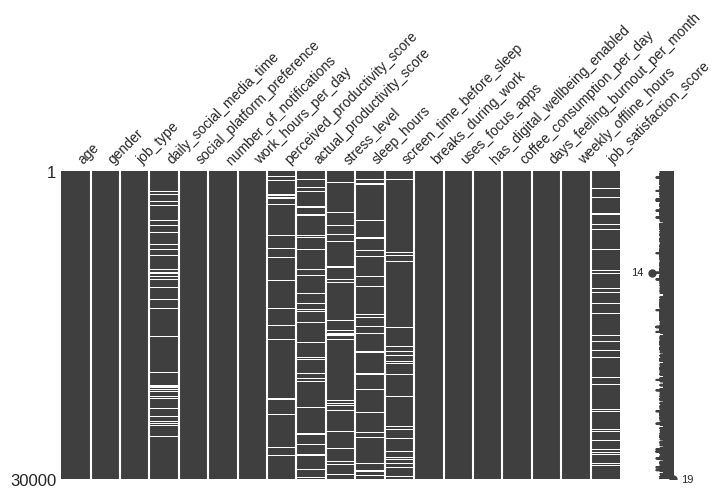

In [27]:
#!pip install missingno -> missingno kütüphanesini kullanabilmek için öncelikle yüklemeniz lazım.
import missingno as msno
msno.matrix(df, figsize=(8, 4), fontsize=10)
plt.show()

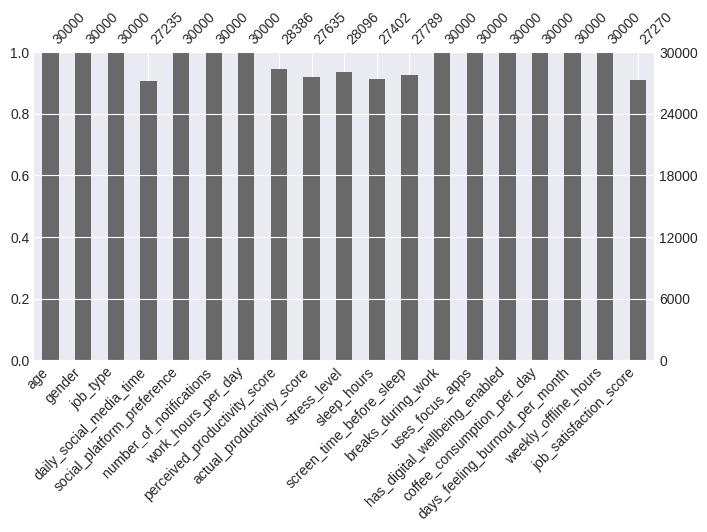

In [28]:
# Eksik verilerin sütun bazlı dağılımını incelemek için bar chart kullanalım.
# Bu grafik, her bir değişkende kaç adet eksik gözlem bulunduğunu görmemizi sağlar.
# Eksikliği yüksek olan değişkenler, ileride özel olarak ele alınmalıdır.

msno.bar(df, figsize=(8, 4), fontsize=10)
plt.show()

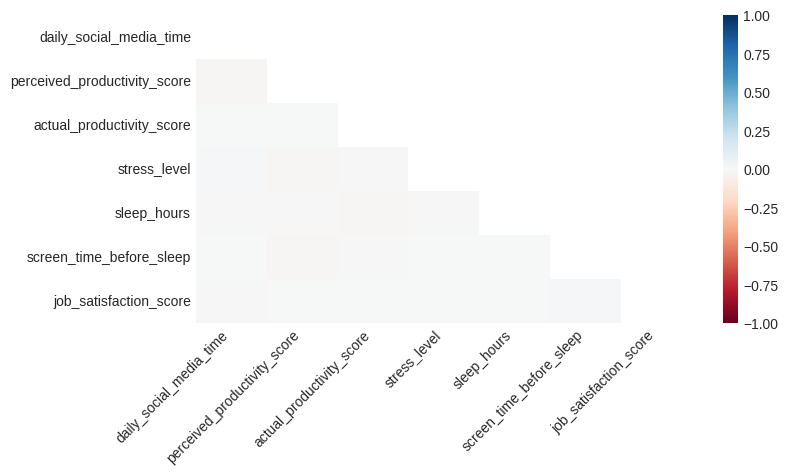

In [29]:
# Eksik veriler arasındaki ilişkiyi incelemek için heatmap kullanalım.
# Bu grafik, sütunlardaki eksik değerlerin birlikte ortaya çıkıp çıkmadığını gösterir.
# Korelasyon değeri 1'e yaklaştıkça, eksikliklerin birlikte oluşma ihtimali artar.
# 0'a yakın değerler ise değişkenler arasında anlamlı bir ilişki olmadığını ifade eder.

msno.heatmap(df, figsize=(8, 4), fontsize=10)
plt.show()

**2.2 Yöntem 1: Eksik Verilerin Silinmesi**

Eksik verilerle başa çıkma yöntemlerinden biri, eksik değer içeren satır veya sütunların veri setinden tamamen silinmesidir. Bu yöntem uygulanması oldukça kolay olsa da, doğrudan kullanılmadan önce veri seti dikkatli bir şekilde analiz edilmelidir.

Eksik değerlerin silinmesi durumunda ilgili satır veya sütundaki diğer bilgiler de veri setinden kaldırılmış olur. Bu nedenle eksik verilerin oranı düşükse bu yöntem tercih edilebilir. Ancak eksik değerlerin oranı yüksekse veri kaybı yaşanabilir ve bu durum analiz sonuçlarını olumsuz etkileyebilir.

Bu nedenle eksik veri silme işlemi uygulanmadan önce:

- Eksik verilerin oranı

- Eksik değerlerin hangi sütunlarda bulunduğu

- Veri setinin genel yapısı

gibi faktörler dikkatlice değerlendirilmelidir.

İlk olarak, Pandas’ın dropna() metodunu kullanarak eksik değerlere sahip gözlemleri veri setinden geçici olarak silelim.
Burada amacımız, silme işleminin veri setini nasıl etkilediğini gözlemlemek.

In [30]:
# Eksik verilerin dropna() ile silinmesi
# inplace=False olduğu için veri seti üzerinde kalıcı bir değişiklik yapılmaz

df.dropna(inplace=False).head()

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
6,56,Female,Unemployed,4.381070,TikTok,60,3.902309,6.420989,5.976408,7.0,7.549849,2.252624,4,False,False,4,20,24.084905,5.501373
7,36,Female,Education,4.089168,Twitter,49,6.560467,2.681830,2.446927,4.0,6.325507,0.747998,2,False,False,4,29,8.419648,3.444376
10,28,Male,IT,3.341559,Twitter,57,11.022035,8.940636,7.983252,4.0,3.952547,1.028640,5,True,True,1,3,13.514515,9.414637


Bazı durumlarda bir satırdaki tüm sütunlar eksik (NaN) olabilir.
Bu tür gözlemler veri setine hiçbir bilgi katkısı sağlamaz. Böyle bir durumda yalnızca tamamen boş olan satırları silmek daha kontrollü bir yaklaşım olabilir.

In [31]:
# Sadece tüm değerleri eksik (tamamı NaN) olan gözlemleri silmek
# Bu işlem kalıcı değildir

df.dropna(how='all').head()

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
2,32,Male,Finance,NaN,Twitter,57,7.910952,3.861762,3.474053,4.0,8.583222,0.624378,0,True,False,3,17,10.322044,2.474944
3,60,Female,Unemployed,NaN,Facebook,59,6.355027,2.916331,1.774869,6.0,6.052984,1.204540,1,False,False,0,4,23.876616,1.733670
4,25,Male,IT,NaN,Telegram,66,6.214096,8.868753,NaN,7.0,5.405706,1.876254,1,False,True,1,30,10.653519,9.693060


Bazı durumlarda eksik değerler satırlarda değil, belirli değişkenlerde yoğunlaşmış olabilir.
Bu gibi senaryolarda, eksik veri içeren kolonların tamamen silinmesi tercih edilebilir.

In [32]:
# Değişken (kolon) bazında eksik veri içeren sütunları silmek
# axis=1 → kolonlar üzerinde işlem yapılacağını belirtir
# Bu işlem kalıcı değildir

df.dropna(axis=1)

,age,gender,job_type,social_platform_preference,number_of_notifications,work_hours_per_day,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours
0,56,Male,Unemployed,Facebook,61,6.753558,8,False,False,4,11,21.927072
1,46,Male,Health,Twitter,59,9.169296,7,True,True,2,25,0.000000
2,32,Male,Finance,Twitter,57,7.910952,0,True,False,3,17,10.322044
3,60,Female,Unemployed,Facebook,59,6.355027,1,False,False,0,4,23.876616
4,25,Male,IT,Telegram,66,6.214096,1,False,True,1,30,10.653519
...,...,...,...,...,...,...,...,...,...,...,...,...
29995,34,Female,Health,Facebook,59,10.226358,9,False,False,4,5,21.776927
29996,39,Male,Health,Instagram,46,4.692862,3,False,False,1,29,4.111370
29997,42,Male,Education,TikTok,64,10.915036,10,False,False,1,2,1.888315
29998,20,Female,Education,Instagram,56,6.937410,1,False,False,2,9,12.511871


**2.3 Yöntem 2: Eksik Verilerin Doldurulması**

Eksik verilerin doldurulması, veri setinden satır veya sütun silmeye kıyasla daha az veri kaybına yol açtığı için veri hazırlama süreçlerinde sıkça kullanılan bir yöntemdir.

Bu yöntemde eksik değerler belirli istatistiksel veya algoritmik yöntemler kullanılarak doldurulur. Ancak doldurma işlemi sırasında veri setine gerçekte var olmayan (sentetik) değerler eklenmiş olur. Bu durum veri dağılımlarını değiştirebilir ve bazı durumlarda analiz sonuçlarını etkileyebilir.

Bu nedenle eksik veri doldurma işlemi uygulanmadan önce aşağıdaki noktalar dikkate alınmalıdır:

- Eksik verilerin oluşma nedeni

- Eksik değerlerin veri setindeki oranı

- İlgili değişkenin analiz açısından önemi

Her veri seti için en uygun doldurma yöntemi farklı olabilir. Bu bölümde yaygın olarak kullanılan eksik veri doldurma yöntemlerini inceleyeceğiz.

**Yaygın Doldurma Yöntemleri**

Eksik verileri doldurmak için sıklıkla kullanılan bazı yöntemler şunlardır:

- Ortalama (Mean) ile doldurma

- Medyan (Median) ile doldurma

- Mod (Mode) ile doldurma

In [33]:
# Doldurma işlemlerini gerçekleştirmek için veri setinin bir kopyasını oluşturma işlemini gerçekleştiriyorum.
df_fillna = df.copy()


In [34]:
df_fillna = df.copy()

# Sayısal değişkenlerin 0 ile doldurulması
for col in numerical_features:
    if df_fillna[col].isnull().any():
        df_fillna[col] = df_fillna[col].fillna(0)

# Kategorik değişkenlerin 'Missing' (Eksik) ifadesiyle veya mod değerleriyle doldurulması.
# Gösterim amacıyla şimdilik 'Missing' ifadesini kullanıyoruz.
for col in categorical_features:
    if df_fillna[col].isnull().any():
        # Add 'Missing' to categories first
        if 'Missing' not in df_fillna[col].cat.categories:
            df_fillna[col] = df_fillna[col].cat.add_categories('Missing')
        df_fillna[col] = df_fillna[col].fillna('Missing')

In [35]:
df_fillna.head(3)

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
2,32,Male,Finance,0.000000,Twitter,57,7.910952,3.861762,3.474053,4.0,8.583222,0.624378,0,True,False,3,17,10.322044,2.474944


In [36]:
df_fillna.isna().sum()

,0
age,0
gender,0
job_type,0
daily_social_media_time,0
social_platform_preference,0
number_of_notifications,0
work_hours_per_day,0
perceived_productivity_score,0
actual_productivity_score,0
stress_level,0


In [37]:
# Sütun adlarını kontrol edelim
df_fillna.columns

Index(['age', 'gender', 'job_type', 'daily_social_media_time',
       'social_platform_preference', 'number_of_notifications',
       'work_hours_per_day', 'perceived_productivity_score',
       'actual_productivity_score', 'stress_level', 'sleep_hours',
       'screen_time_before_sleep', 'breaks_during_work', 'uses_focus_apps',
       'has_digital_wellbeing_enabled', 'coffee_consumption_per_day',
       'days_feeling_burnout_per_month', 'weekly_offline_hours',
       'job_satisfaction_score'],
      dtype='object')

**2.3.1 Sayısal Değişkenlerin Doldurulması**

In [38]:
# sleep_hours değişkeninin ortalamasını hesaplayalım
mean_sleep_hours = df_fillna['sleep_hours'].mean()

# sleep_hours sütunundaki eksik değerleri ortalama ile dolduralım
df_fillna['sleep_hours'] = df_fillna['sleep_hours'].fillna(mean_sleep_hours)

df_fillna.isna().sum()

,0
age,0
gender,0
job_type,0
daily_social_media_time,0
social_platform_preference,0
number_of_notifications,0
work_hours_per_day,0
perceived_productivity_score,0
actual_productivity_score,0
stress_level,0


In [39]:
# Doldurma işleminin döngüyle yapılması
to_be_filled = numerical_features[1:]

for col in to_be_filled:
    df_fillna[col] = df_fillna[col].fillna(df_fillna[col].mean())

df_fillna.isna().sum()

,0
age,0
gender,0
job_type,0
daily_social_media_time,0
social_platform_preference,0
number_of_notifications,0
work_hours_per_day,0
perceived_productivity_score,0
actual_productivity_score,0
stress_level,0


In [40]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,30000.0,41.486867,13.835221,18.000000,30.000000,41.000000,53.000000,65.000000
daily_social_media_time,27235.0,3.113418,2.074813,0.000000,1.639566,3.025913,4.368917,17.973256
number_of_notifications,30000.0,59.958767,7.723772,30.000000,55.000000,60.000000,65.000000,90.000000
work_hours_per_day,30000.0,6.990792,1.997736,0.000000,5.643771,6.990641,8.354725,12.000000
perceived_productivity_score,28386.0,5.510488,2.023470,2.000252,3.757861,5.525005,7.265776,8.999376
actual_productivity_score,27635.0,4.951805,1.883378,0.296812,3.373284,4.951742,6.526342,9.846258
stress_level,28096.0,5.514059,2.866344,1.000000,3.000000,6.000000,8.000000,10.000000
sleep_hours,27402.0,6.500247,1.464004,3.000000,5.493536,6.498340,7.504143,10.000000
screen_time_before_sleep,27789.0,1.025568,0.653355,0.000000,0.528490,1.006159,1.477221,3.000000
breaks_during_work,30000.0,4.992200,3.173737,0.000000,2.000000,5.000000,8.000000,10.000000


Sayısal değişkenlerde eksik değerler ortalama (mean) kullanılarak doldurulmuştur. Ancak veri dağılımının simetrik olmadığı, kuyruklu (skewed) yapıya sahip olduğu durumlarda ortalama değer uç gözlemlerden etkilenebilir. Bu gibi durumlarda, daha dayanıklı bir ölçü olan medyan (median) değeri ile doldurma işlemi tercih edilebilir.

In [41]:
df_fillna[col] = df_fillna[col].fillna(df_fillna[col].median())

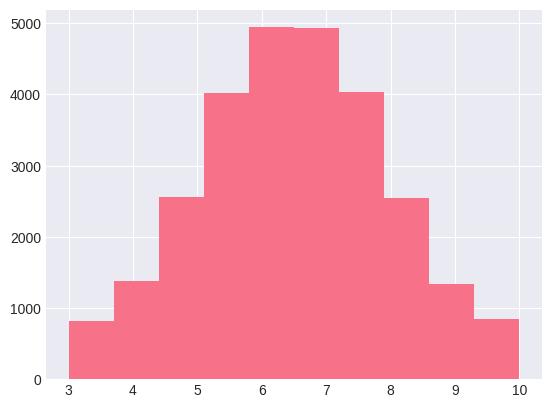

In [42]:
# Bir sayısal değişkenin dağılımını görmek için histogram kullanılabilir.
plt.hist(df['sleep_hours'])
plt.show()

**2.3.2 Kategorik Değişkenlerin Doldurulması**

Kategorik değişkenlerde eksik değerleri doldurmak için en sık tekrar eden değer (mode) yaygın olarak kullanılan bir yöntemdir. Bu yaklaşım, özellikle kategoriler arasında belirgin bir baskın sınıf bulunduğu durumlarda tercih edilir.

In [43]:
# Kategorik bir değişkenin mode değeriyle doldurulması

# gender değişkeninde toplam kaç adet eksik değer olduğunu görelim.
df_fillna['gender'].isna().sum()

# gender değişkeninde en çok tekrar eden değeri(mode) alalım.
gender_mode = df_fillna['gender'].mode()

# gender değişkenini mode değeri ile dolduralım.
df_fillna['gender'] = df_fillna['gender'].fillna(value = gender_mode[0])

# gender değişkeninde toplam kaç adet eksik değer olduğunu tekrar görelim.
df_fillna.isna().sum()

,0
age,0
gender,0
job_type,0
daily_social_media_time,0
social_platform_preference,0
number_of_notifications,0
work_hours_per_day,0
perceived_productivity_score,0
actual_productivity_score,0
stress_level,0


In [44]:
df_fillna[["job_type"]][:20]

,job_type
0,Unemployed
1,Health
2,Finance
3,Unemployed
4,IT
5,Finance
6,Unemployed
7,Education
8,Education
9,IT


In [45]:
# Önceki değer ile doldurma işlemi
df_fillna["job_type"].fillna(method = "bfill")

,job_type
0,Unemployed
1,Health
2,Finance
3,Unemployed
4,IT
...,...
29995,Health
29996,Health
29997,Education
29998,Education


In [46]:
# Sonraki değer ile doldurma işlemi
df_fillna["job_type"].fillna(method = "ffill")

,job_type
0,Unemployed
1,Health
2,Finance
3,Unemployed
4,IT
...,...
29995,Health
29996,Health
29997,Education
29998,Education


**2.3.3 Kategorik Kırılım ile Eksik Veri Doldurma**

Basitçe `mean` veya `median` değerleri ile eksik verileri doldurmak hızlı bir çözüm sağlar; ancak her zaman en doğru yaklaşım değildir. Daha analitik bir yöntem, eksik verileri veri içindeki kategorik kırılımlara göre doldurmaktır.

Örneğin, elimizde `salary` (maaş) kolonu var ve bu kolonda eksik veriler bulunuyor. Sadece genel ortalama veya medyan ile doldurmak yerine, elimizde `job_title` (iş pozisyonu) kolonu olduğunu biliyoruz. Bu durumda, eksik bir maaş verisini, aynı `job_title` grubuna ait maaşların ortalama veya medyan değeri ile doldurmak daha doğru olur.  

Farklı pozisyonların maaşları farklı olacağından, eksik maaşı kendi grubunun istatistiksel değerine göre doldurmak, veriyi daha anlamlı hâle getirir.

In [47]:
df_categorical_fillna = df.copy()

df_categorical_fillna.isna().sum()

,0
age,0
gender,0
job_type,0
daily_social_media_time,2765
social_platform_preference,0
number_of_notifications,0
work_hours_per_day,0
perceived_productivity_score,1614
actual_productivity_score,2365
stress_level,1904


In [48]:
gender_mode = df_categorical_fillna['gender'].mode()[0]
df_categorical_fillna['gender'].fillna(value=gender_mode, inplace=True)

In [49]:
df_categorical_fillna.isna().sum()

,0
age,0
gender,0
job_type,0
daily_social_media_time,2765
social_platform_preference,0
number_of_notifications,0
work_hours_per_day,0
perceived_productivity_score,1614
actual_productivity_score,2365
stress_level,1904


In [50]:
df_categorical_fillna[df_categorical_fillna[["gender", "job_type"]].isna().all(axis=1)][["gender", "job_type"]]

,gender,job_type


In [51]:
df_categorical_fillna[df_categorical_fillna['gender'].isnull()]

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score


**2.3.4 Makine Öğrenmesi ile Eksik Veri Doldurma**

Eksik verileri doldurmak için sadece basit istatistiksel yöntemler değil, **makine öğrenmesi modelleri** de kullanılabilir. Bu yöntemler, veri setindeki diğer kolonlardaki ilişkileri öğrenerek eksik değerleri tahmin eder.  

Aşağıdaki modeller kullanılabilir:

- **KNNImputer (K-Nearest Neighbor)**: Benzer gözlemleri bulup eksik değeri tahmin eder.  
- **Random Forest Classifier/Regressor**: Eksik değerleri diğer değişkenlerden tahmin etmek için ağaç tabanlı modeller kullanır.  

Daha detaylı örnek ve uygulamalar için Google’da şu sorguları arayabilirsiniz:  
- `"How can I fill missing values by using Machine Learning techniques in Python?"`  
- `"Python ile eksik verileri Makine Öğrenmesi teknikleri kullanarak nasıl doldurabilirim?"`  

In [52]:
from sklearn.impute import KNNImputer

# 1. Sadece sayısal sütunları seçelim (KNN kategorik verilerle doğrudan çalışmaz)
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# 2. Imputer nesnesini oluşturalım (n_neighbors genelde 5 seçilir)
imputer = KNNImputer(n_neighbors=5)

# 3. Eksik değerleri tahmin edip dolduralım
df_filled_array = imputer.fit_transform(numeric_df)

# 4. Sonucu tekrar bir DataFrame haline getirelim
df_filled = pd.DataFrame(df_filled_array, columns=numeric_df.columns)

# Kontrol
print(df_filled.isnull().sum())

age                               0
daily_social_media_time           0
number_of_notifications           0
work_hours_per_day                0
perceived_productivity_score      0
actual_productivity_score         0
stress_level                      0
sleep_hours                       0
screen_time_before_sleep          0
breaks_during_work                0
coffee_consumption_per_day        0
days_feeling_burnout_per_month    0
weekly_offline_hours              0
job_satisfaction_score            0
dtype: int64


**3. Kategorik Değişken Analizi**

In [53]:
df = df.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   age                             30000 non-null  int64   
 1   gender                          30000 non-null  category
 2   job_type                        30000 non-null  category
 3   daily_social_media_time         27235 non-null  float64 
 4   social_platform_preference      30000 non-null  category
 5   number_of_notifications         30000 non-null  int64   
 6   work_hours_per_day              30000 non-null  float64 
 7   perceived_productivity_score    28386 non-null  float64 
 8   actual_productivity_score       27635 non-null  float64 
 9   stress_level                    28096 non-null  float64 
 10  sleep_hours                     27402 non-null  float64 
 11  screen_time_before_sleep        27789 non-null  float64 
 12  breaks_during_work

**3.1 Kategorik Değişken İşlemleri**

#### Kategorik Değişkenlerin Seçilmesi

Veri setinde belirli bir veri tipine sahip kolonları seçmek için `select_dtypes()` fonksiyonu kullanılabilir.  
Bu veri setinde kategorik değişkenler `object` yerine `category` veri tipi ile temsil edilmektedir.


In [54]:
# Veri tipi 'category' olan (kategorik) değişkenleri seçme
df_categorical = df.select_dtypes(include="category")

# İlk 3 gözlemi görüntüleme
df_categorical.head(3)

,gender,job_type,social_platform_preference
0,Male,Unemployed,Facebook
1,Male,Health,Twitter
2,Male,Finance,Twitter


Bir kategorik değişkenin kaç farklı sınıfa sahip olduğunu ve bu sınıfların neler olduğunu görmek için
`unique()` fonksiyonu kullanılabilir. Aşağıda `social_platform_preference` değişkenine ait benzersiz değerler incelenmiştir.

In [55]:
# 'social_platform_preference' değişkenindeki benzersiz değerleri görüntüleme
df_categorical["social_platform_preference"].unique()

['Facebook', 'Twitter', 'Telegram', 'TikTok', 'Instagram']
Categories (5, object): ['Facebook', 'Instagram', 'Telegram', 'TikTok', 'Twitter']

In [56]:
# Kategorik değişkenlerdeki benzersiz değerlerin sayısını görebilmek için nunique() kullanabiliriz.
for col in df_categorical.columns:
    print(f'There are {df_categorical[col].nunique()} unique values in "{col}" categorical feature.\n')

There are 3 unique values in "gender" categorical feature.

There are 6 unique values in "job_type" categorical feature.

There are 5 unique values in "social_platform_preference" categorical feature.



In [57]:
# Her bir kategorik değişken için toplam gözlem sayısını value_counts() ile buluyoruz.
for col in df_categorical.columns:
    print(f'{df_categorical[col].value_counts()}\n', 5*"*********")

gender
Male      14452
Female    14370
Other      1178
Name: count, dtype: int64
 *********************************************
job_type
Education     5055
IT            5026
Finance       5017
Student       5012
Unemployed    4958
Health        4932
Name: count, dtype: int64
 *********************************************
social_platform_preference
TikTok       6096
Telegram     6013
Instagram    6006
Twitter      5964
Facebook     5921
Name: count, dtype: int64
 *********************************************


In [58]:
# Kategorik bir değişkende bulunan kategorik değerleri bir liste haline getirip sonra kullanabiliriz.
gender_categories = df["gender"].unique().tolist()[::-1]
gender_categories

['Other', 'Female', 'Male']

In [59]:
# Ordinal değişken nasıl oluşturulur?
from pandas.api.types import CategoricalDtype

df["gender"] = df["gender"].astype(CategoricalDtype(categories = gender_categories, ordered = True))

In [60]:
df["gender"].head()

,gender
0,Male
1,Male
2,Male
3,Female
4,Male


**3.2 Kategorik Değişkenlerde Görselleştirme İşlemleri**

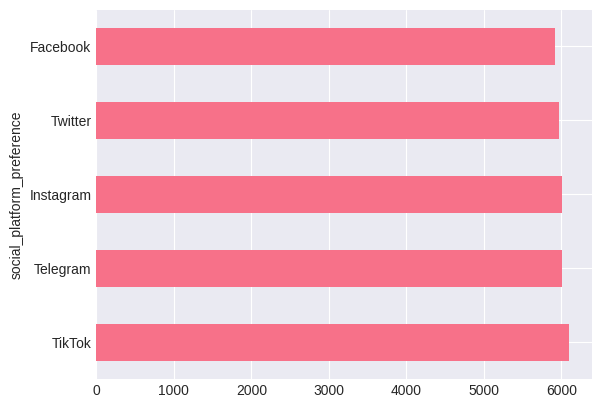

In [61]:
# Kategorik bir değişkendeki kategorilerin gözlem sayılarını basitçe görselleştirelim.
df['social_platform_preference'].value_counts().plot.barh();

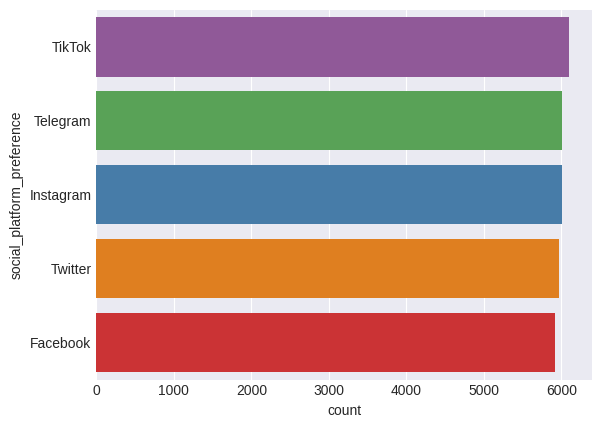

In [62]:
sns.countplot(data = df,
              y = "social_platform_preference",
              hue = "social_platform_preference",
              order = df["social_platform_preference"].value_counts().index,
              palette = "Set1");

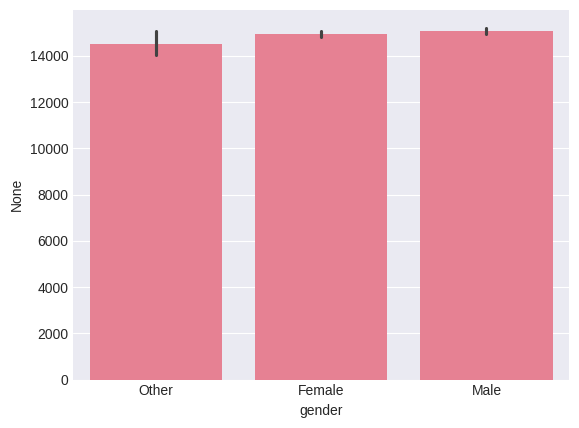

In [63]:
sns.barplot(data = df, x = "gender", y = df.gender.index);

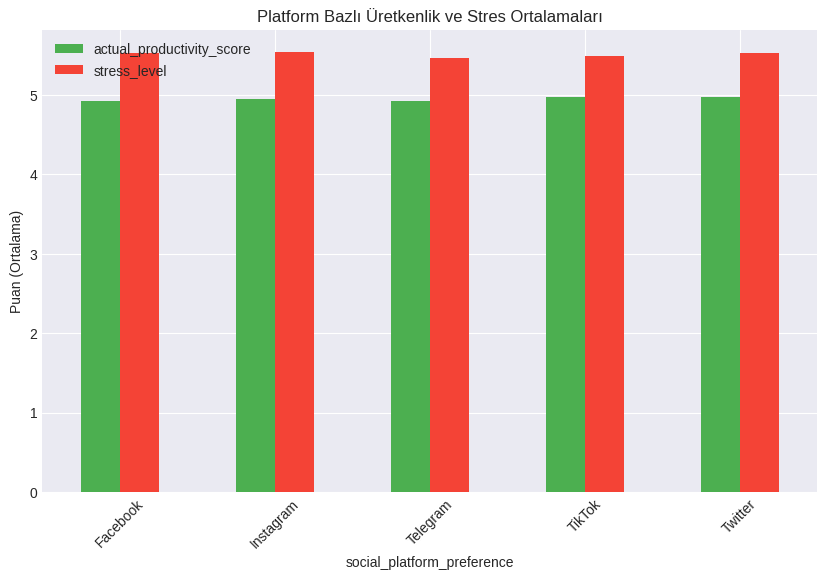

In [64]:
# Gruplama işlemi
platform_stats = df.groupby('social_platform_preference')[['actual_productivity_score', 'stress_level']].mean()

# Görselleştirme
platform_stats.plot(kind='bar', figsize=(10,6), color=['#4CAF50', '#F44336'])
plt.title('Platform Bazlı Üretkenlik ve Stres Ortalamaları')
plt.ylabel('Puan (Ortalama)')
plt.xticks(rotation=45)
plt.show()

In [65]:
# Örnek: Sosyal platform tercihlerine göre ortalama günlük sosyal medya süresi
platform_avg = df.groupby("social_platform_preference")["daily_social_media_time"].mean()
platform_avg

,daily_social_media_time
social_platform_preference,
Facebook,3.143080
Instagram,3.095693
Telegram,3.081423
TikTok,3.169280
Twitter,3.076726


Cinsiyet ve tercih edilen platform kombinasyonunun, alınan bildirim sayısı (number_of_notifications) üzerindeki etkisini görelim

In [66]:
# Cinsiyet ve Platform bazında bildirim yoğunluğu
notification_density = df.groupby(['gender', 'social_platform_preference'])['number_of_notifications'].describe()
# Sadece ortalama ve maksimum değerlere odaklanalım
print(notification_density[['mean', 'max']])

                                        mean   max
gender social_platform_preference                 
Other  Facebook                    59.606335  84.0
       Instagram                   59.816964  83.0
       Telegram                    60.215768  82.0
       TikTok                      60.551587  81.0
       Twitter                     60.416667  84.0
Female Facebook                    60.164248  87.0
       Instagram                   60.197075  85.0
       Telegram                    59.925810  87.0
       TikTok                      59.642614  87.0
       Twitter                     59.986383  89.0
Male   Facebook                    59.964522  87.0
       Instagram                   59.794502  89.0
       Telegram                    59.988969  90.0
       TikTok                      60.032347  89.0
       Twitter                     59.828671  90.0


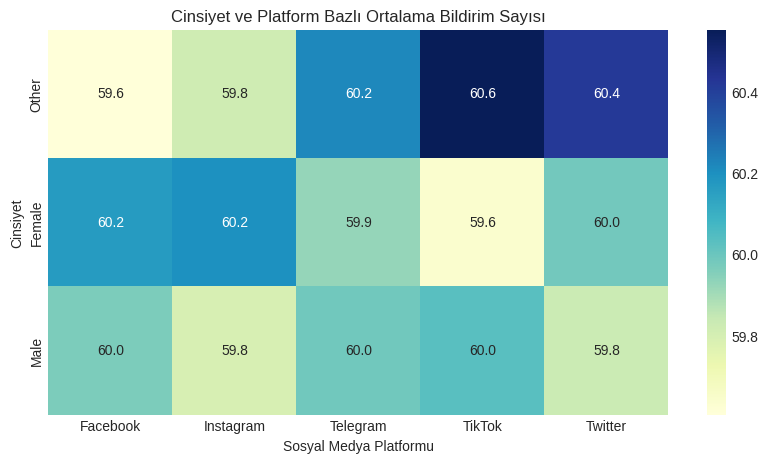

In [67]:
# Veriyi pivot tablo haline getirelim (Heatmap için gereklidir)
notif_map = df.pivot_table(index='gender', columns='social_platform_preference', values='number_of_notifications', aggfunc='mean')

# Görselleştirme
plt.figure(figsize=(10, 5))
sns.heatmap(notif_map, annot=True, cmap='YlGnBu', fmt='.1f')

plt.title('Cinsiyet ve Platform Bazlı Ortalama Bildirim Sayısı')
plt.xlabel('Sosyal Medya Platformu')
plt.ylabel('Cinsiyet')
plt.show()

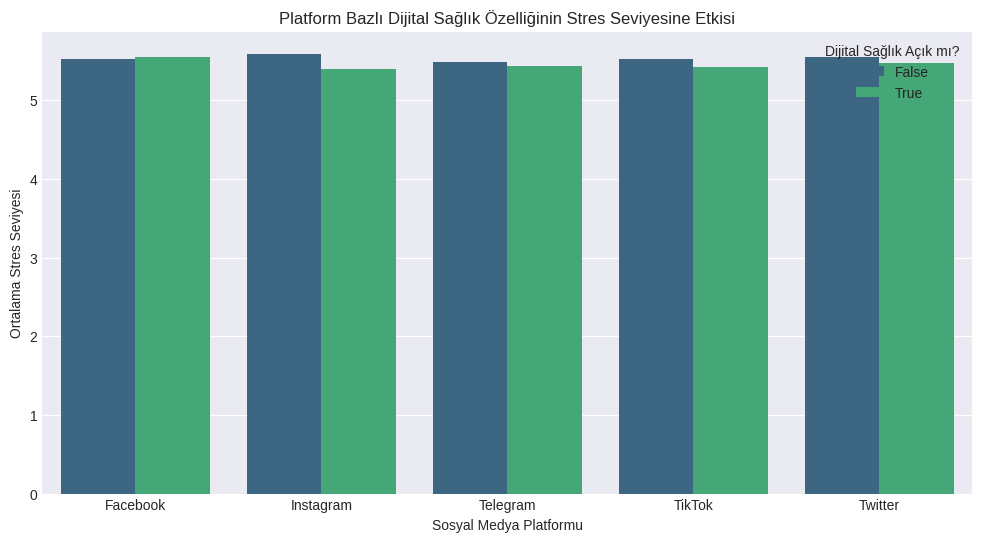

In [68]:
# Veriyi gruplayıp ortalamasını alalım
wellbeing_stress = df.groupby(['social_platform_preference', 'has_digital_wellbeing_enabled'])['stress_level'].mean().reset_index()

# Görselleştirme
plt.figure(figsize=(12, 6))
sns.barplot(data=wellbeing_stress, x='social_platform_preference', y='stress_level', hue='has_digital_wellbeing_enabled', palette='viridis')

plt.title('Platform Bazlı Dijital Sağlık Özelliğinin Stres Seviyesine Etkisi')
plt.xlabel('Sosyal Medya Platformu')
plt.ylabel('Ortalama Stres Seviyesi')
plt.legend(title='Dijital Sağlık Açık mı?', loc='upper right')
plt.show()

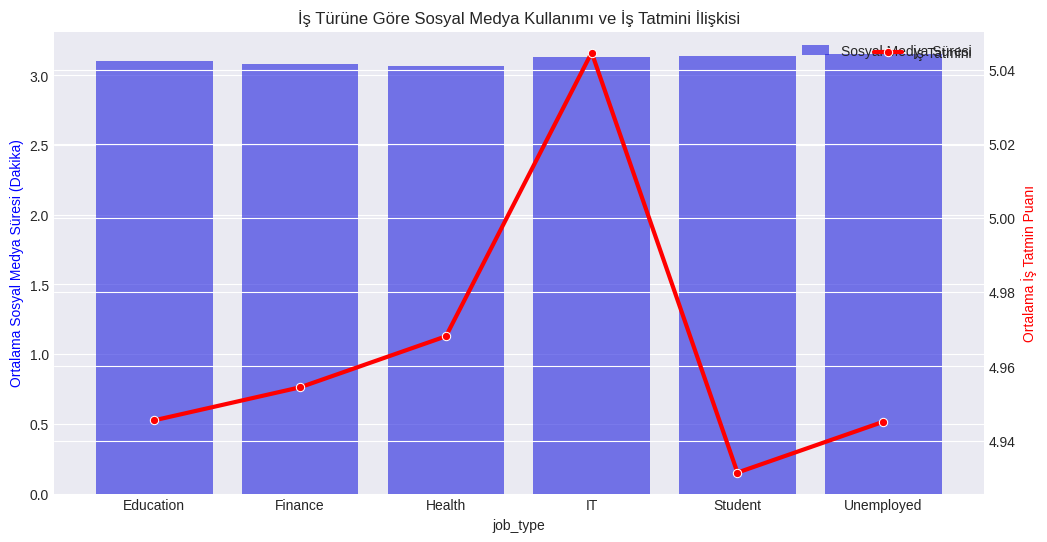

In [69]:
# Veriyi gruplayalım
job_analysis = df.groupby('job_type')[['daily_social_media_time', 'job_satisfaction_score']].mean()

# İki farklı ölçek olduğu için (süre ve puan) yan yana iki grafik (subplot) çizelim
fig, ax1 = plt.subplots(figsize=(12, 6))

# Sol eksen: Sosyal Medya Süresi
sns.barplot(x=job_analysis.index, y=job_analysis['daily_social_media_time'], ax=ax1, alpha=0.6, color='blue', label='Sosyal Medya Süresi')
ax1.set_ylabel('Ortalama Sosyal Medya Süresi (Dakika)', color='blue')

# Sağ eksen: İş Tatmin Puanı
ax2 = ax1.twinx()
sns.lineplot(x=job_analysis.index, y=job_analysis['job_satisfaction_score'], ax=ax2, marker='o', color='red', linewidth=3, label='İş Tatmini')
ax2.set_ylabel('Ortalama İş Tatmin Puanı', color='red')

plt.title('İş Türüne Göre Sosyal Medya Kullanımı ve İş Tatmini İlişkisi')
plt.show()

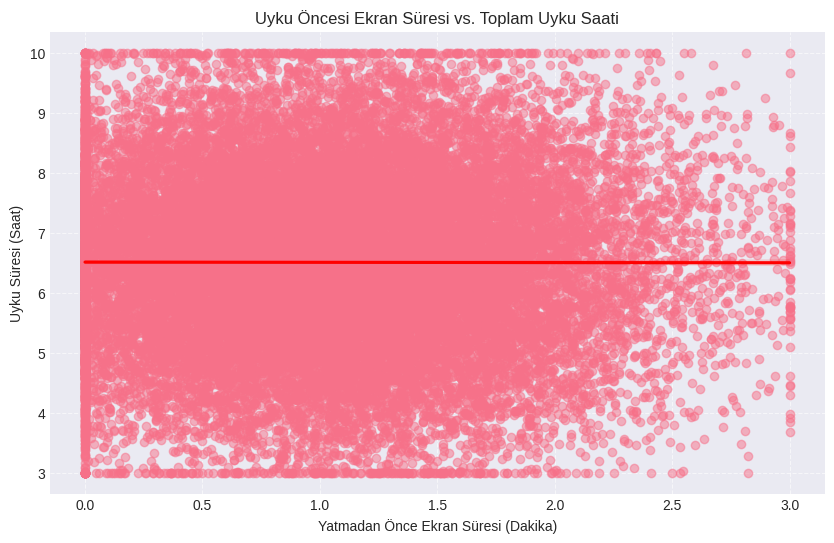

In [70]:
plt.figure(figsize=(10, 6))
# Noktaların yoğunluğunu görmek için regülasyon çizgisi (regplot) ekleyelim
sns.regplot(data=df, x='screen_time_before_sleep', y='sleep_hours',
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title('Uyku Öncesi Ekran Süresi vs. Toplam Uyku Saati')
plt.xlabel('Yatmadan Önce Ekran Süresi (Dakika)')
plt.ylabel('Uyku Süresi (Saat)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

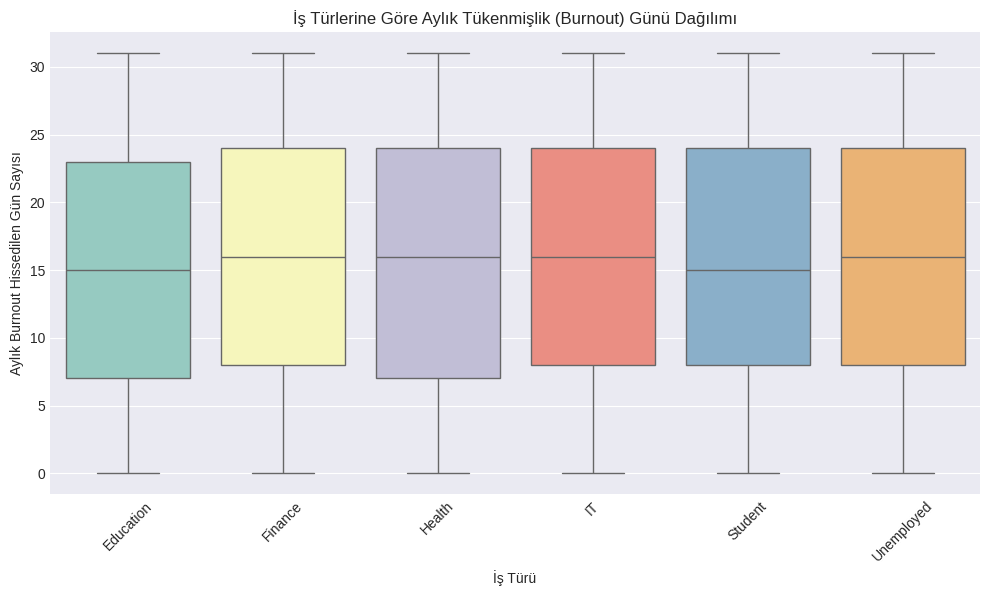

In [71]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='job_type', y='days_feeling_burnout_per_month', palette='Set3')

plt.title('İş Türlerine Göre Aylık Tükenmişlik (Burnout) Günü Dağılımı')
plt.xlabel('İş Türü')
plt.ylabel('Aylık Burnout Hissedilen Gün Sayısı')
plt.xticks(rotation=45)
plt.show()

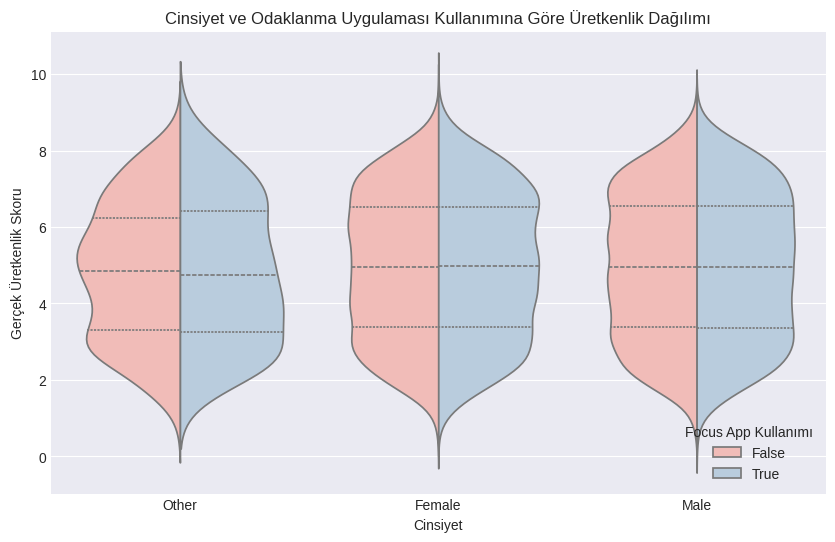

In [72]:
plt.figure(figsize=(10, 6))
# 'split=True' ile iki grubu tek bir gövdede karşılaştırabiliriz
sns.violinplot(data=df, x='gender', y='actual_productivity_score',
               hue='uses_focus_apps', split=True, inner="quart", palette='Pastel1')

plt.title('Cinsiyet ve Odaklanma Uygulaması Kullanımına Göre Üretkenlik Dağılımı')
plt.xlabel('Cinsiyet')
plt.ylabel('Gerçek Üretkenlik Skoru')
plt.legend(title='Focus App Kullanımı', loc='lower right')
plt.show()

**3.3 Kategorik Gruplama (groupby) İşlemleri**

Kategorik gruplama işlemleri, veri setindeki belirli kategorik değişkenlere göre sayısal değişkenlerin istatistiksel özetlerini incelemek için kullanılır. Bu sayede farklı gruplar arasındaki benzerlikler ve farklılıklar daha net bir şekilde analiz edilebilir.

Bu bölümde Social Media Productivity veri seti kullanılarak, kullanıcıların dijital alışkanlıkları ile üretkenlik ve psikolojik durumları arasındaki ilişkiler incelenmiştir. Analiz kapsamında şu temel sorulara yanıt aranmıştır:

- Platform Etkisi: Tercih edilen sosyal medya platformuna (social_platform_preference) göre günlük kullanım süresi ve stres seviyesi nasıl değişmektedir?

- Çalışma Modeli ve Tatmin: Farklı iş türlerinde (job_type) çalışan bireylerin sosyal medya kullanım alışkanlıkları ile iş tatmini (job_satisfaction_score) arasındaki denge nasıldır?

- Dijital Sağlık ve Odaklanma: Odaklanma uygulamaları (uses_focus_apps) ve dijital sağlık özelliklerinin (has_digital_wellbeing_enabled) kullanımı, gerçek üretkenlik skorları (actual_productivity_score) üzerinde anlamlı bir fark yaratmakta mıdır?

In [73]:
df.head()

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
2,32,Male,Finance,NaN,Twitter,57,7.910952,3.861762,3.474053,4.0,8.583222,0.624378,0,True,False,3,17,10.322044,2.474944
3,60,Female,Unemployed,NaN,Facebook,59,6.355027,2.916331,1.774869,6.0,6.052984,1.204540,1,False,False,0,4,23.876616,1.733670
4,25,Male,IT,NaN,Telegram,66,6.214096,8.868753,NaN,7.0,5.405706,1.876254,1,False,True,1,30,10.653519,9.693060


In [74]:
# Örnek: Platform tercihlerine göre temel metriklerin özeti
platform_summary = df.groupby("social_platform_preference")[["daily_social_media_time", "actual_productivity_score", "stress_level"]].mean()
display(platform_summary.sort_values(by="actual_productivity_score", ascending=False))

,daily_social_media_time,actual_productivity_score,stress_level
social_platform_preference,,,
TikTok,3.169280,4.979062,5.499387
Twitter,3.076726,4.972400,5.527406
Instagram,3.095693,4.954962,5.546036
Facebook,3.143080,4.927949,5.525231
Telegram,3.081423,4.923759,5.472721


In [75]:
# 1. Önce hesaplamayı yapalım
job_health_stats = df.groupby("job_type")[["stress_level", "days_feeling_burnout_per_month", "job_satisfaction_score"]].agg(["mean", "min", "max"])

# 2. Şık bir tasarım uygulayalım
display(job_health_stats.style
        .format("{:.2f}") # Tüm sayıları 2 basamağa yuvarla
        .background_gradient(cmap='YlGnBu', axis=0) # Sütun bazlı renk geçişi ekle
        .set_caption("Meslek Gruplarına Göre Psikolojik Durum ve Memnuniyet Analizi")
        .set_properties(**{'text-align': 'center', 'border': '1px solid white'}))

In [76]:
# 1. Gruplama işlemini yapalım
focus_impact = df.groupby("uses_focus_apps")[["actual_productivity_score", "number_of_notifications"]].mean()

# 2. Şık ve tek başlıklı tablo tasarımı
focus_impact.style \
    .format("{:.2f}") \
    .set_caption("Odaklanma Uygulaması (Focus App) Kullanımının Verimlilik ve Bildirim Sayısına Etkisi") \
    .background_gradient(cmap='Blues', subset=['actual_productivity_score']) \
    .bar(subset=['number_of_notifications'], color='#f5a623') \
    .set_properties(**{'text-align': 'center', 'padding': '10px'})

,actual_productivity_score,number_of_notifications
uses_focus_apps,,
False,4.95,59.94
True,4.95,60.01


In [77]:
# 1. Önce pivotu yapalım
sleep_analysis = df.groupby(["gender", "has_digital_wellbeing_enabled"])["sleep_hours"].mean().unstack()

# 2. Şık bir tablo formatında yazdıralım
print("\n--- Gelişmiş Uyku Analizi Tablosu ---")
display(sleep_analysis.style.highlight_max(axis=0, color='lightgreen').highlight_min(axis=0, color='pink').format(precision=2))


--- Gelişmiş Uyku Analizi Tablosu ---


has_digital_wellbeing_enabled,False,True
gender,,
Other,6.48,6.51
Female,6.49,6.50
Male,6.51,6.50


In [78]:
# Kahve tüketim miktarına göre algılanan üretkenlik ve stres seviyesi
# 1. Gruplama işlemini yapalım
coffee_impact = df.groupby("coffee_consumption_per_day")[["perceived_productivity_score", "stress_level"]].mean()

# 2. Şık ve görselleştirilmiş tablo tasarımı
coffee_impact.style \
    .format("{:.2f}") \
    .set_caption("Kahve Tüketiminin Algılanan Üretkenlik ve Stres Seviyesi Üzerindeki Etkisi") \
    .background_gradient(cmap='Greens', subset=['perceived_productivity_score']) \
    .background_gradient(cmap='Oranges', subset=['stress_level']) \
    .set_properties(**{'text-align': 'center', 'padding': '8px'})

,perceived_productivity_score,stress_level
coffee_consumption_per_day,,
0,5.46,5.55
1,5.54,5.48
2,5.52,5.52
3,5.52,5.56
4,5.46,5.38
5,5.56,5.63
6,5.46,5.69
7,5.61,5.13
8,5.29,4.93


In [79]:
# Veriyi gruplayıp unstack yapalım
sleep_analysis = df.groupby(["gender", "has_digital_wellbeing_enabled"])["sleep_hours"].mean().unstack()

# Şık bir tasarım uygulayalım
print("\n--- Cinsiyet ve Dijital Sağlık Ayarına Göre Uyku Saatleri ---")
display(sleep_analysis.style.format("{:.2f}")  # 2 basamak yuvarla
        .background_gradient(cmap='Blues')    # Değerlere göre mavi tonlaması yap
        .highlight_max(color='lightgreen')     # En yüksek değer yeşil
        .highlight_min(color='#ff9999'))      # En düşük değer kırmızı


--- Cinsiyet ve Dijital Sağlık Ayarına Göre Uyku Saatleri ---


has_digital_wellbeing_enabled,False,True
gender,,
Other,6.48,6.51
Female,6.49,6.50
Male,6.51,6.50


`reset_index()` kullanılarak grup bazlı hesaplanan sonuçlar tablo formatına dönüştürülmüştür.
Bu yapı, görselleştirme işlemleri için daha uygundur.

In [80]:
# 1. reset_index() kullanmadan: Veri 'Series' veya 'MultiIndex' yapısında kalır
# 2. reset_index() kullanarak: Veri standart bir DataFrame (Tablo) haline gelir

# İş türüne göre ortalama stres seviyesini hesaplayıp tabloya dönüştürelim
job_stress_table = df.groupby("job_type")["stress_level"].mean().reset_index()

# Sonucu şık bir formatta gösterelim
job_stress_table.style \
    .format({"stress_level": "{:.2f}"}) \
    .set_caption("reset_index() ile Tablo Formatına Dönüştürülmüş İş-Stres Analizi") \
    .background_gradient(cmap='Reds', subset=['stress_level'])

,job_type,stress_level
0,Education,5.51
1,Finance,5.59
2,Health,5.50
3,IT,5.54
4,Student,5.47
5,Unemployed,5.47


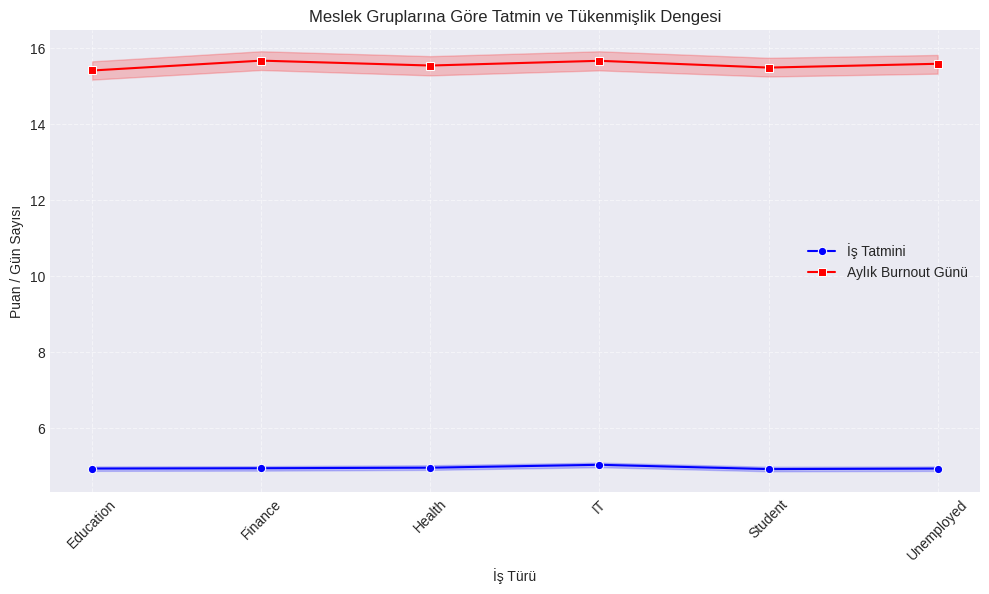

In [81]:
# 2. İş Türüne Göre İş Tatmini ve Burnout (Tükenmişlik) İlişkisi
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='job_type', y='job_satisfaction_score', marker='o', label='İş Tatmini', color='blue')
sns.lineplot(data=df, x='job_type', y='days_feeling_burnout_per_month', marker='s', label='Aylık Burnout Günü', color='red')

plt.title('Meslek Gruplarına Göre Tatmin ve Tükenmişlik Dengesi')
plt.ylabel('Puan / Gün Sayısı')
plt.xlabel('İş Türü')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**4. Sürekli Değişken Analizi**

Sürekli değişken analizi, sayısal verilerin dağılımını, merkezi eğilimini (ortalama, medyan) ve değişkenliğini incelememizi sağlar. Bu analiz, verideki eğilimleri anlamak ve ileride yapılacak modelleme çalışmaları için uygun teknikleri belirlemek adına gereklidir.

4.1 Sürekli Değişkenlerin İncelenmesi

Bu bölümde, veri setindeki int64 ve float64 tipindeki tüm sayısal değişkenler ayrıştırılarak temel istatistiksel özetleri çıkarılmıştır.

In [82]:
# Veri setindeki numerik kolonları seçmek için aşağıdaki yapıyı kullanabiliriz.
df_numerical = df.select_dtypes(include = ["float64", "int64"])
df_numerical.head()

,age,daily_social_media_time,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,4.180940,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,4,11,21.927072,6.336688
1,46,3.249603,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,2,25,0.000000,3.412427
2,32,NaN,57,7.910952,3.861762,3.474053,4.0,8.583222,0.624378,0,3,17,10.322044,2.474944
3,60,NaN,59,6.355027,2.916331,1.774869,6.0,6.052984,1.204540,1,0,4,23.876616,1.733670
4,25,NaN,66,6.214096,8.868753,NaN,7.0,5.405706,1.876254,1,1,30,10.653519,9.693060


In [83]:
df_numerical.describe().T

,count,mean,std,min,25%,50%,75%,max
age,30000.0,41.486867,13.835221,18.000000,30.000000,41.000000,53.000000,65.000000
daily_social_media_time,27235.0,3.113418,2.074813,0.000000,1.639566,3.025913,4.368917,17.973256
number_of_notifications,30000.0,59.958767,7.723772,30.000000,55.000000,60.000000,65.000000,90.000000
work_hours_per_day,30000.0,6.990792,1.997736,0.000000,5.643771,6.990641,8.354725,12.000000
perceived_productivity_score,28386.0,5.510488,2.023470,2.000252,3.757861,5.525005,7.265776,8.999376
actual_productivity_score,27635.0,4.951805,1.883378,0.296812,3.373284,4.951742,6.526342,9.846258
stress_level,28096.0,5.514059,2.866344,1.000000,3.000000,6.000000,8.000000,10.000000
sleep_hours,27402.0,6.500247,1.464004,3.000000,5.493536,6.498340,7.504143,10.000000
screen_time_before_sleep,27789.0,1.025568,0.653355,0.000000,0.528490,1.006159,1.477221,3.000000
breaks_during_work,30000.0,4.992200,3.173737,0.000000,2.000000,5.000000,8.000000,10.000000


In [84]:
def stats_overview(dataframe: pd.DataFrame) -> pd.DataFrame:
    num_df = dataframe.select_dtypes(include=["int", "float"])

    stats_df = num_df.agg(['mean', 'std', 'min', 'max', 'median', 'count']).T

    return stats_df

In [85]:
stats_overview(df)

,mean,std,min,max,median,count
age,41.486867,13.835221,18.000000,65.000000,41.000000,30000.0
daily_social_media_time,3.113418,2.074813,0.000000,17.973256,3.025913,27235.0
number_of_notifications,59.958767,7.723772,30.000000,90.000000,60.000000,30000.0
work_hours_per_day,6.990792,1.997736,0.000000,12.000000,6.990641,30000.0
perceived_productivity_score,5.510488,2.023470,2.000252,8.999376,5.525005,28386.0
actual_productivity_score,4.951805,1.883378,0.296812,9.846258,4.951742,27635.0
stress_level,5.514059,2.866344,1.000000,10.000000,6.000000,28096.0
sleep_hours,6.500247,1.464004,3.000000,10.000000,6.498340,27402.0
screen_time_before_sleep,1.025568,0.653355,0.000000,3.000000,1.006159,27789.0
breaks_during_work,4.992200,3.173737,0.000000,10.000000,5.000000,30000.0


Bu çıktı, veri setindeki sayısal değişkenlere ait temel istatistiksel bilgileri göstermektedir.

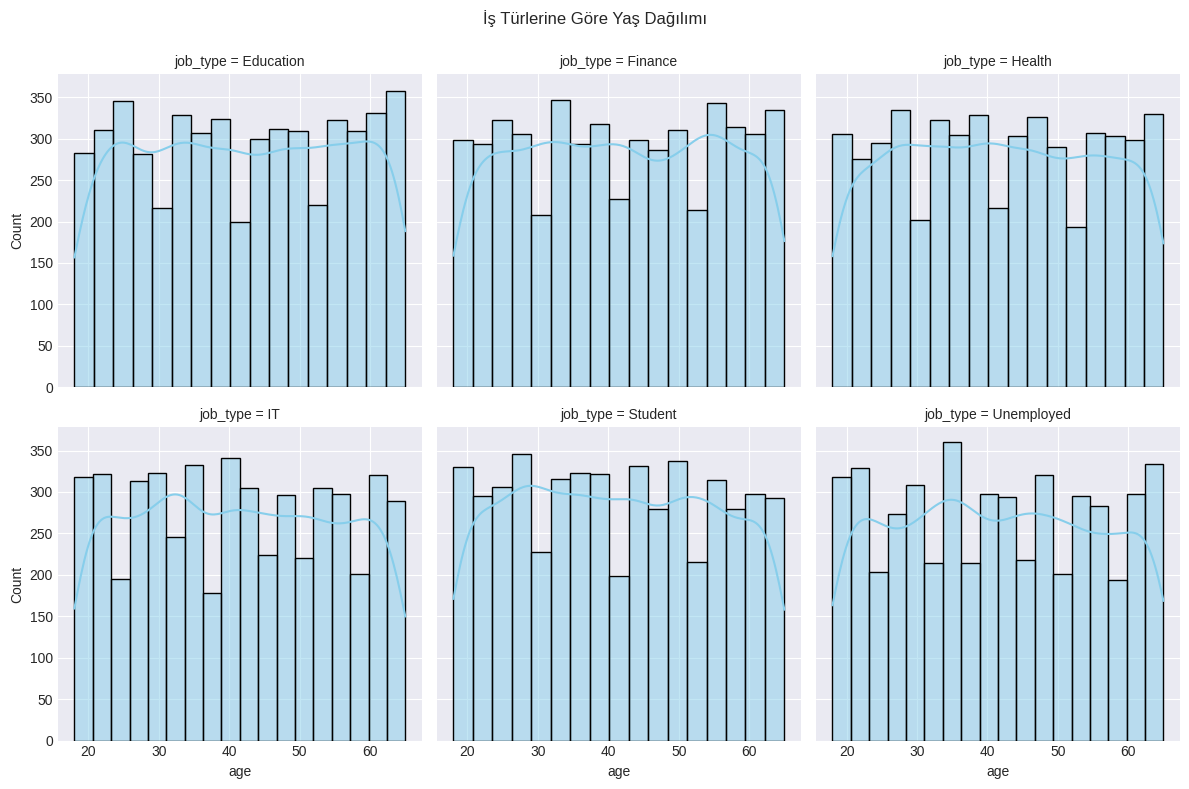

In [86]:
# Her iş türü için ayrı bir panel oluşturur
g = sns.FacetGrid(df, col="job_type", col_wrap=3, height=4)
g.map(sns.histplot, "age", kde=True, color="skyblue")

plt.subplots_adjust(top=0.9)
g.fig.suptitle('İş Türlerine Göre Yaş Dağılımı')
plt.show()

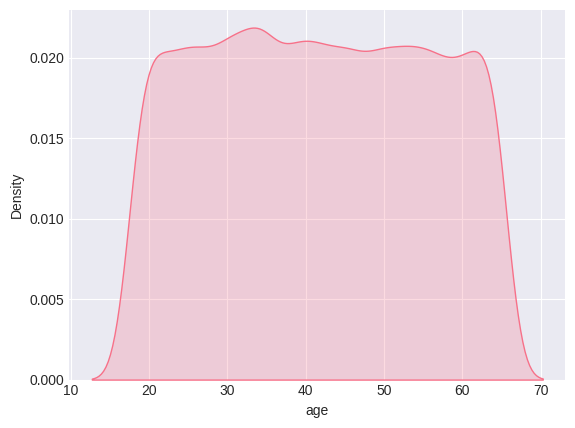

In [87]:
# kdeplot ise ilgili numerik değişkenin yoğunluğunu gösterir.
sns.kdeplot(df['age'], fill = True);

In [88]:
!pip install joypy

**Ridge Plot (Sevin Plot): Yoğunluk Karşılaştırması**
Eğer amacımız grupların dağılım şekillerini (tepe noktalarını) birbiriyle kıyaslamaksa, "Ridge Plot" çok estetik ve bilgilendirici bir seçenektir.

<Figure size 1200x800 with 0 Axes>

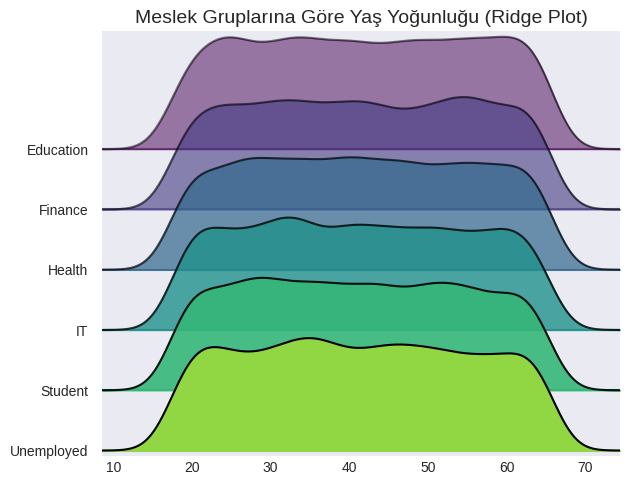

In [89]:
from joypy import joyplot
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(12, 8))
fig, axes = joyplot(df, column='age', by='job_type', ylim='tight',
                    colormap=plt.cm.viridis, alpha=0.8, fade=True)

plt.title('Meslek Gruplarına Göre Yaş Yoğunluğu (Ridge Plot)', fontsize=14)
plt.show()

**Box Plot ve Swarm Plot Kombinasyonu**
Sadece dağılımı değil, her bir veri noktasının nerede durduğunu ve aykırı değerleri (outliers) görmek istiyorsak bu ikili en iyi çözümdür.

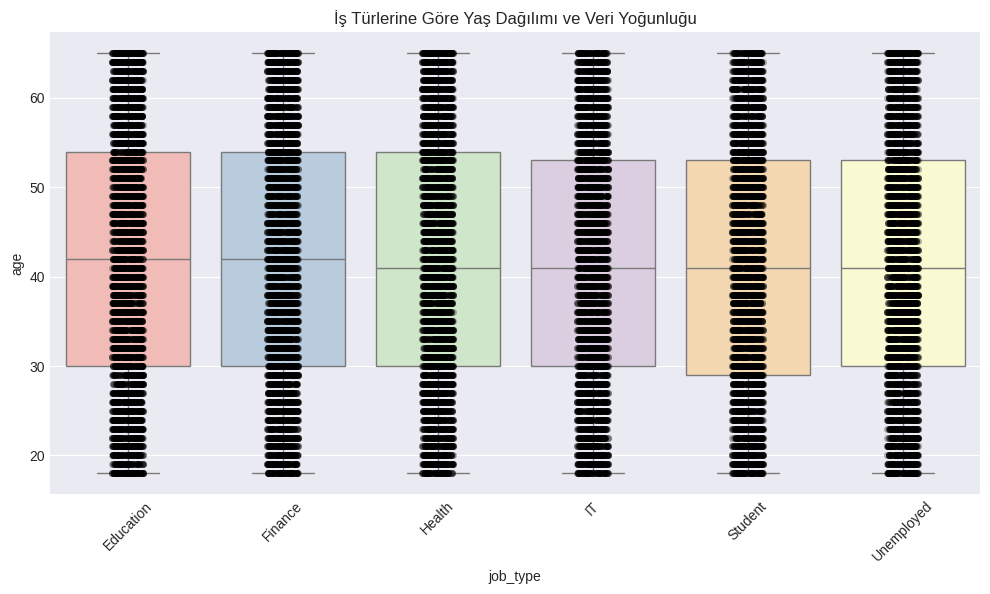

In [90]:
plt.figure(figsize=(12, 6))

# Kutucuk grafiği ana yapıyı gösterir
sns.boxplot(data=df, x="job_type", y="age", palette="Pastel1", showfliers=False)

# Swarmplot her bir veriyi nokta olarak üzerine ekler (Veri seti çok büyükse 'stripplot' kullanabilirsin)
sns.stripplot(data=df, x="job_type", y="age", color="black", alpha=0.3)

plt.title('İş Türlerine Göre Yaş Dağılımı ve Veri Yoğunluğu')
plt.xticks(rotation=45)
plt.show()

FacetGrid ve KDE plot kullanılırken, çizilen sayısal değişkenin değer aralığına
uygun eksen sınırlarının belirlenmesi gerekmektedir. Aksi halde yoğunluk grafikleri
görünmeyebilir.

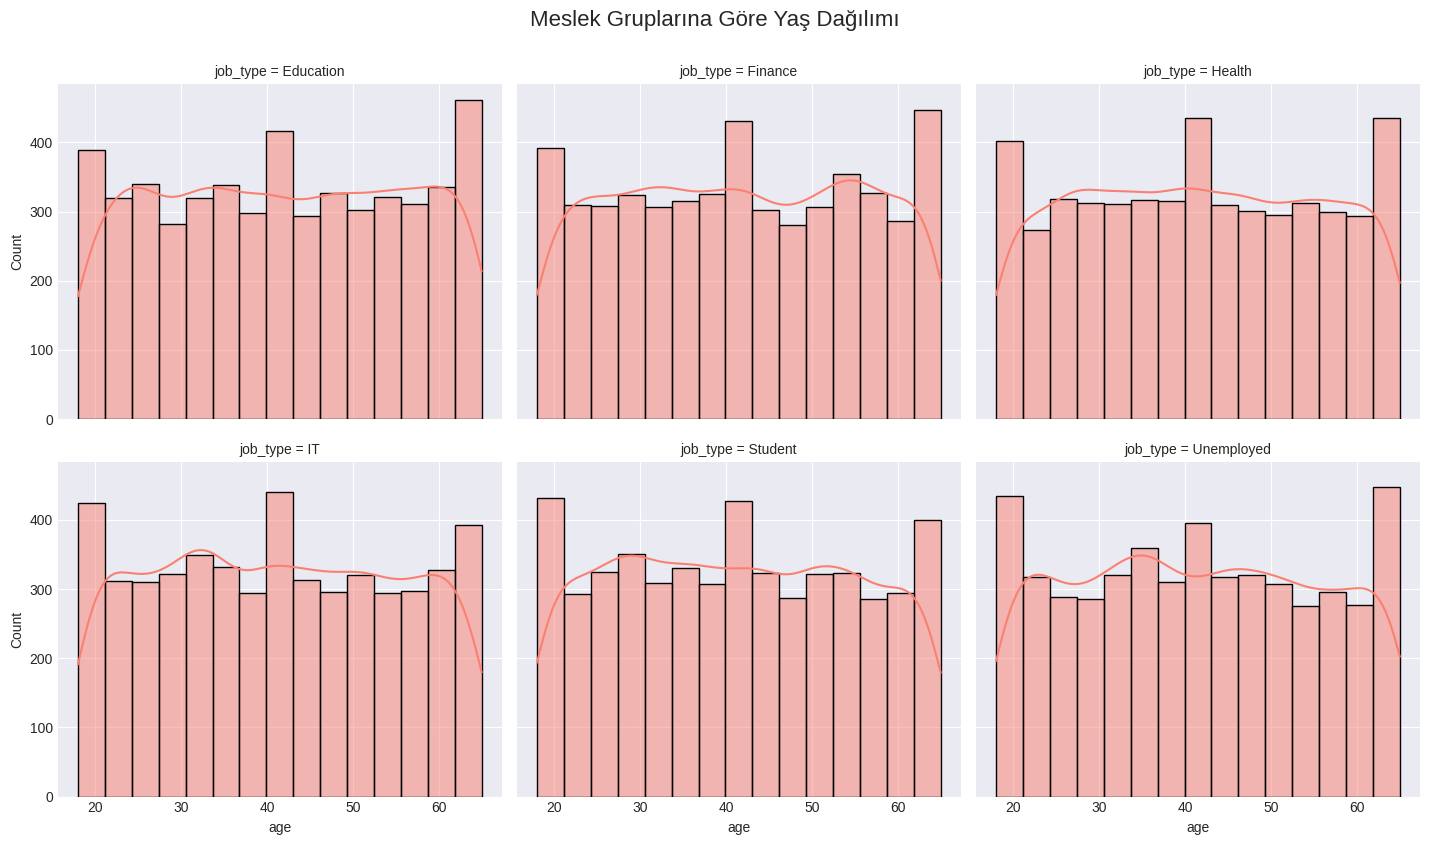

In [91]:
# Her iş türü için ayrı bir grafik kutucuğu oluşturur
g = sns.FacetGrid(df, col="job_type", col_wrap=3, height=4, aspect=1.2)
g.map(sns.histplot, "age", kde=True, color="salmon", bins=15)

# Başlık ve düzenleme
g.fig.suptitle('Meslek Gruplarına Göre Yaş Dağılımı', fontsize=16, y=1.05)
plt.show()

**Scatterplot (dağılım grafiği)**, iki sayısal değişken arasındaki ilişkiyi görselleştirmek için kullanılır. Noktaların konumu sayesinde değişkenler arasındaki korelasyon, eğilimler, kümelenmeler ve aykırı değerler kolayca gözlemlenebilir. Kategorik bir değişken ise hue parametresiyle renk ayrımı yapılarak analize dahil edilebilir.

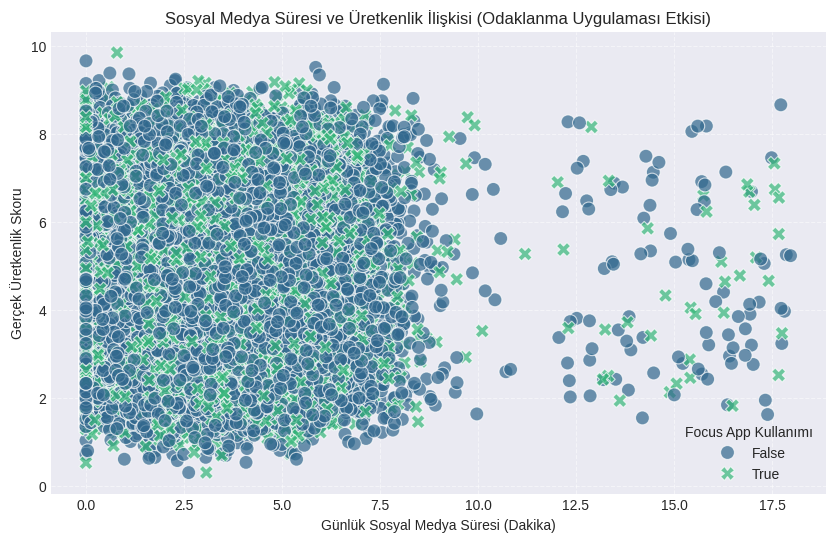

In [92]:
plt.figure(figsize=(10, 6))
# Sosyal medya süresi arttıkça üretkenlik nasıl değişiyor?
# Focus App kullananlar (hue) bu durumdan nasıl etkileniyor?
sns.scatterplot(data=df, x="daily_social_media_time", y="actual_productivity_score",
                hue="uses_focus_apps", style="uses_focus_apps", palette="viridis", s=100, alpha=0.7)

plt.title('Sosyal Medya Süresi ve Üretkenlik İlişkisi (Odaklanma Uygulaması Etkisi)')
plt.xlabel('Günlük Sosyal Medya Süresi (Dakika)')
plt.ylabel('Gerçek Üretkenlik Skoru')
plt.legend(title="Focus App Kullanımı")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Pairplot, veri setindeki sayısal değişkenler arasındaki ikili ilişkileri ve her bir değişkenin kendi dağılımını aynı anda görselleştirmeye yarayan bir Seaborn grafik türüdür. Keşifsel veri analizi (EDA) aşamasında değişkenler arasındaki korelasyonları, örüntüleri ve olası aykırı değerleri hızlıca incelemek için kullanılır.

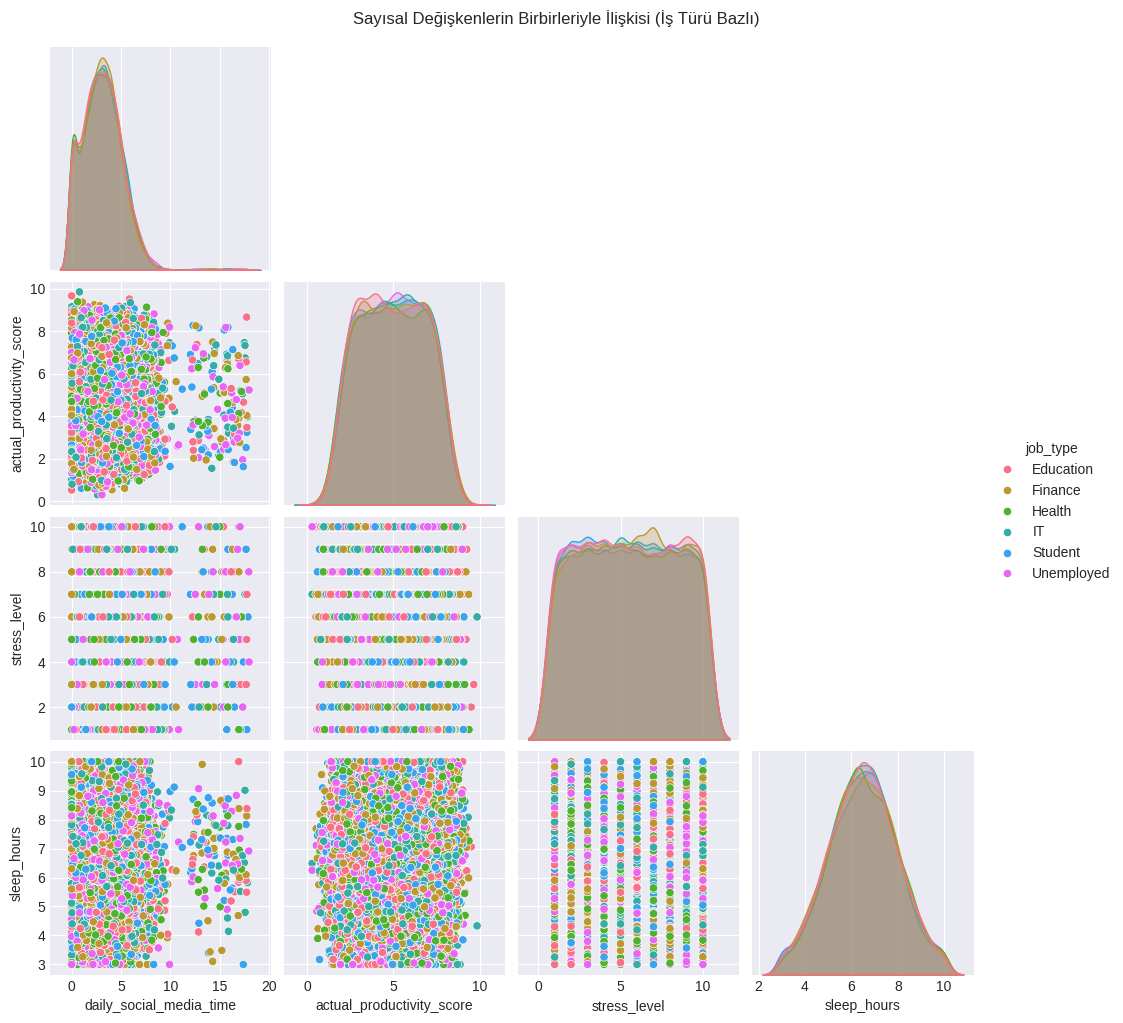

In [93]:
# Analiz edilecek anahtar değişkenleri seçelim
selected_cols = ["daily_social_media_time", "actual_productivity_score", "stress_level", "sleep_hours", "job_type"]

# Pairplot oluşturma (job_type bazında renklendirme)
sns.pairplot(df[selected_cols], hue="job_type", palette="husl", corner=True, diag_kind="kde")

plt.suptitle('Sayısal Değişkenlerin Birbirleriyle İlişkisi (İş Türü Bazlı)', y=1.02)
plt.show()

**Heatmap (ısı haritası)**, sayısal değişkenler arasındaki korelasyonları corr() fonksiyonu ile hesaplanan korelasyon matrisi üzerinden görselleştirmek için kullanılan bir grafiktir. Renk yoğunluğu, değişkenler arasındaki ilişkinin gücünü ve yönünü (pozitif / negatif) gösterir ve veri setindeki ilişkileri hızlıca fark etmeyi sağlar.

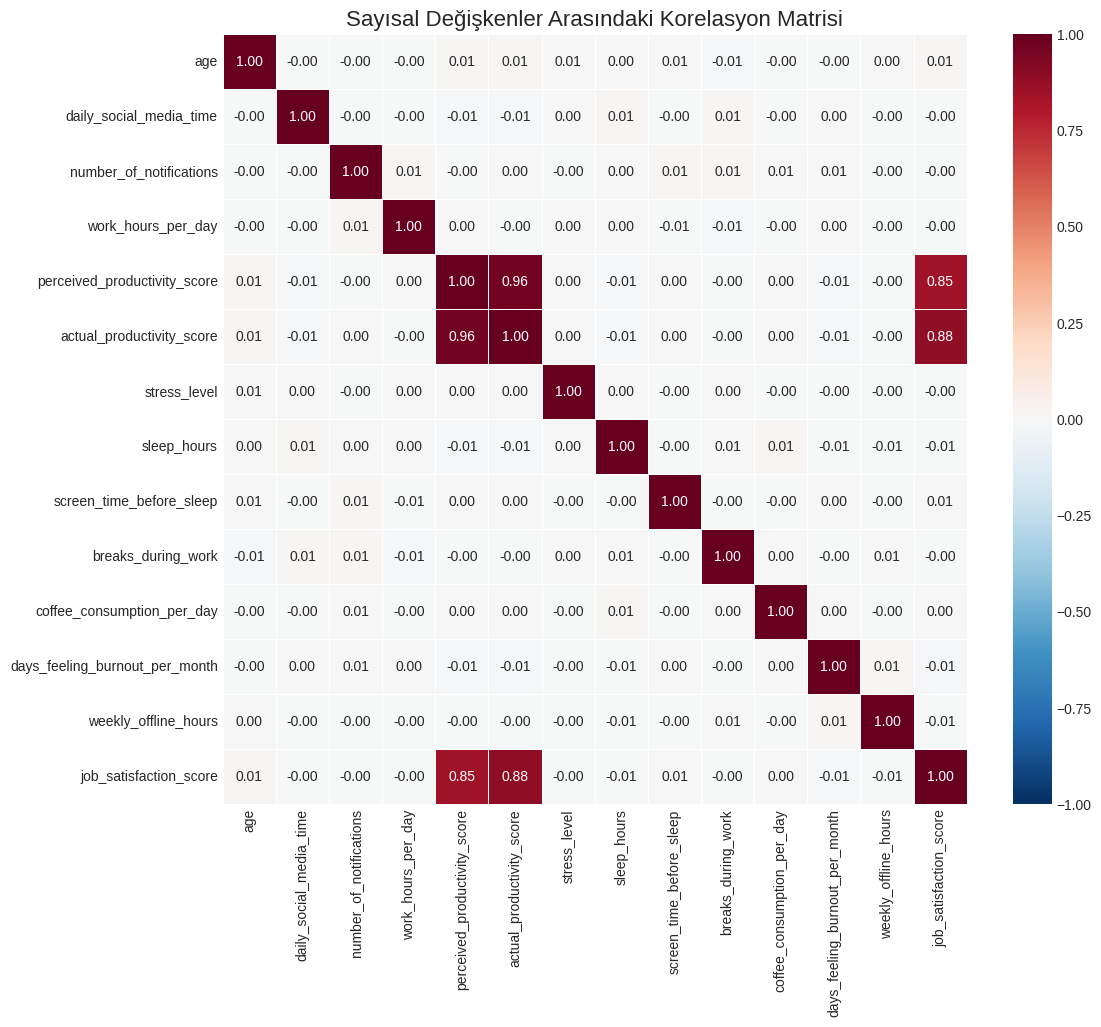

In [94]:
# 1. Sadece sayısal sütunları seçelim ve korelasyon matrisini hesaplayalım
# Not: corr() fonksiyonu varsayılan olarak Pearson korelasyonunu hesaplar.
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# 2. Isı Haritasını (Heatmap) çizelim
plt.figure(figsize=(12, 10))

# annot=True: Karelerin içine korelasyon katsayılarını yazar.
# cmap='RdBu_r': Pozitif ilişkileri mavi, negatifleri kırmızı gösterir (sezgiseldir).
# vmin, vmax: Renk skalasını -1 ile 1 arasına sabitler.
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.5)

plt.title('Sayısal Değişkenler Arasındaki Korelasyon Matrisi', fontsize=16)
plt.show()

**5. Aykırı Değer Analizi (Outliers)**

Aykırı değerler, veri setindeki genel dağılımdan önemli ölçüde sapma gösteren gözlemlerdir. Tıpkı eksik verilerde olduğu gibi aykırı değerler de dikkatle ele alınmalıdır. Aykırı değerlerin varlığı; ortalama, standart sapma gibi istatistiksel ölçüleri bozabilir ve bu durum makine öğrenmesi modellerinin genellenebilirliğini olumsuz etkileyebilir.

Aykırı değerlerin tespiti ve değerlendirilmesi için farklı yöntemler bulunmaktadır:

- Sektörel / alan bilgisi

- Standart sapma yaklaşımı

- Z-skoru

- IQR (Interquartile Range) yöntemi

In [95]:
df = df.copy()

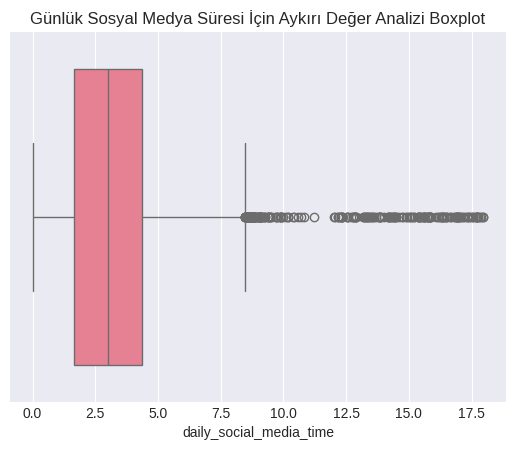

In [96]:
# Boxplot örneği
sns.boxplot(x=df["daily_social_media_time"])
plt.title("Günlük Sosyal Medya Süresi İçin Aykırı Değer Analizi Boxplot")
plt.show()

In [97]:
df_daily_social_media_time = df['daily_social_media_time']
df_daily_social_media_time

,daily_social_media_time
0,4.180940
1,3.249603
2,NaN
3,NaN
4,NaN
...,...
29995,1.877297
29996,4.437784
29997,17.724981
29998,3.796634


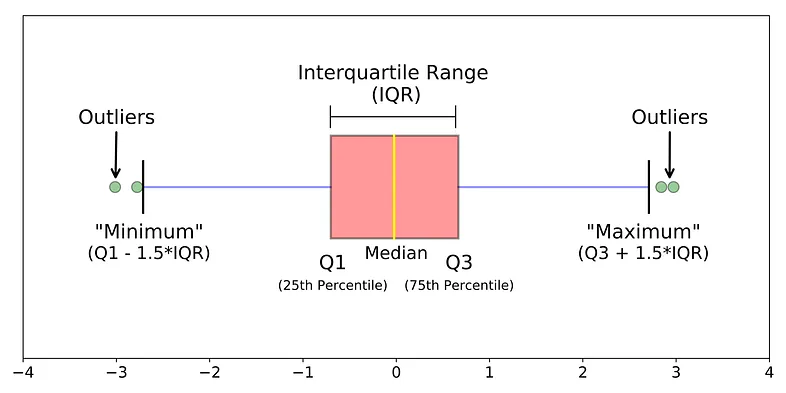

In [98]:
# Alt ve Üst eşik değerlerini belirleyelim (IQR yöntemi)
Q1 = df["daily_social_media_time"].quantile(0.25)
Q3 = df["daily_social_media_time"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Baskılama İşlemi
df_capped = df.copy()
df_capped.loc[df["daily_social_media_time"] > upper_limit, "daily_social_media_time"] = upper_limit
df_capped.loc[df["daily_social_media_time"] < lower_limit, "daily_social_media_time"] = lower_limit

print(f"Baskılama öncesi Max: {df['daily_social_media_time'].max()}")
print(f"Baskılama sonrası Max: {df_capped['daily_social_media_time'].max()}")

Baskılama öncesi Max: 17.973255602826175
Baskılama sonrası Max: 8.462943010683407


In [99]:
# Üst sınırın üzerinde kalan aykırı gözlemlerin index değerleri
outlier_idx = df[df["daily_social_media_time"] > upper_limit].index

outlier_idx

Index([   67,   272,   331,   797,   817,   864,  1011,  1028,  1260,  1337,
       ...
       28947, 28952, 28960, 29416, 29557, 29594, 29609, 29906, 29917, 29997],
      dtype='int64', length=226)

Toplam Aykırı Gözlem Sayısı: 226


,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
67,35,Female,Unemployed,8.694539,Telegram,67,9.509569,6.639874,5.537632,3.0,6.238619,0.500126,8,False,False,1,13,0.000000,5.742396
272,22,Male,Unemployed,12.518832,Twitter,54,6.675880,3.690030,3.805203,3.0,7.931480,0.920126,4,False,True,2,16,9.937156,5.981881
331,38,Female,Student,12.296394,TikTok,62,8.162595,8.834388,8.271057,2.0,8.700196,1.945848,6,False,False,3,11,12.747990,8.378520
797,65,Female,IT,17.817948,Telegram,54,6.806313,4.329849,3.964795,3.0,5.824280,1.404549,9,False,False,5,22,17.970858,5.074375
817,50,Male,Health,8.469030,Facebook,50,9.312894,3.971951,3.791057,6.0,5.986067,1.707691,4,False,False,2,19,6.195724,3.569097


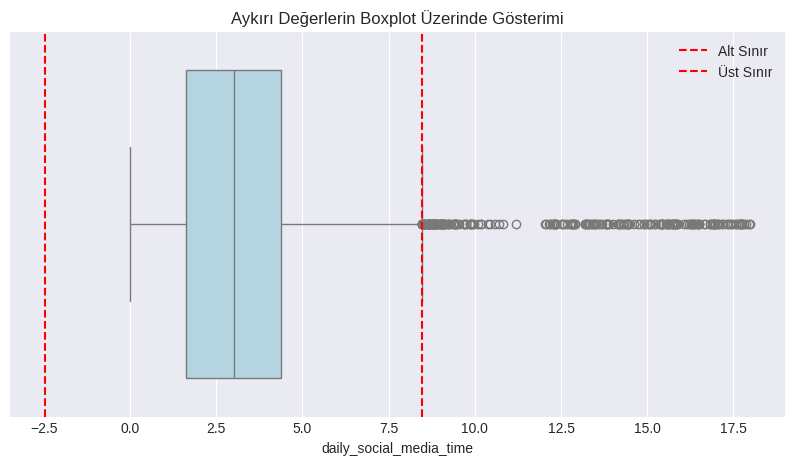

In [100]:
# Belirlediğin sınırlara göre aykırı değerleri filtreleyelim
outliers = df[(df["daily_social_media_time"] < lower_limit) | (df["daily_social_media_time"] > upper_limit)]

print(f"Toplam Aykırı Gözlem Sayısı: {len(outliers)}")
display(outliers.head()) # Aykırı değerlerin kendisine bakalım

plt.figure(figsize=(10, 5))
sns.boxplot(x=df["daily_social_media_time"], color="lightblue")

# Hesapladığın sınırları grafiğe ekleyelim
plt.axvline(x=lower_limit, color='r', linestyle='--', label='Alt Sınır')
plt.axvline(x=upper_limit, color='r', linestyle='--', label='Üst Sınır')

plt.title("Aykırı Değerlerin Boxplot Üzerinde Gösterimi")
plt.legend()
plt.show()

**5.1 Aykırı Gözlemlerin Silinmesi**

In [101]:
Q1 = df["daily_social_media_time"].quantile(0.25)
Q3 = df["daily_social_media_time"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Sadece sınırlar içerisinde kalan verileri alıyoruz
df_filtered = df[(df["daily_social_media_time"] >= lower_limit) &
                 (df["daily_social_media_time"] <= upper_limit)]

print(f"Silinen gözlem sayısı: {len(df) - len(df_filtered)}")

Silinen gözlem sayısı: 2991


IQR yöntemi ile belirlenen alt ve üst sınırların dışında kalan aykırı gözlemler veri setinden silinmiştir.

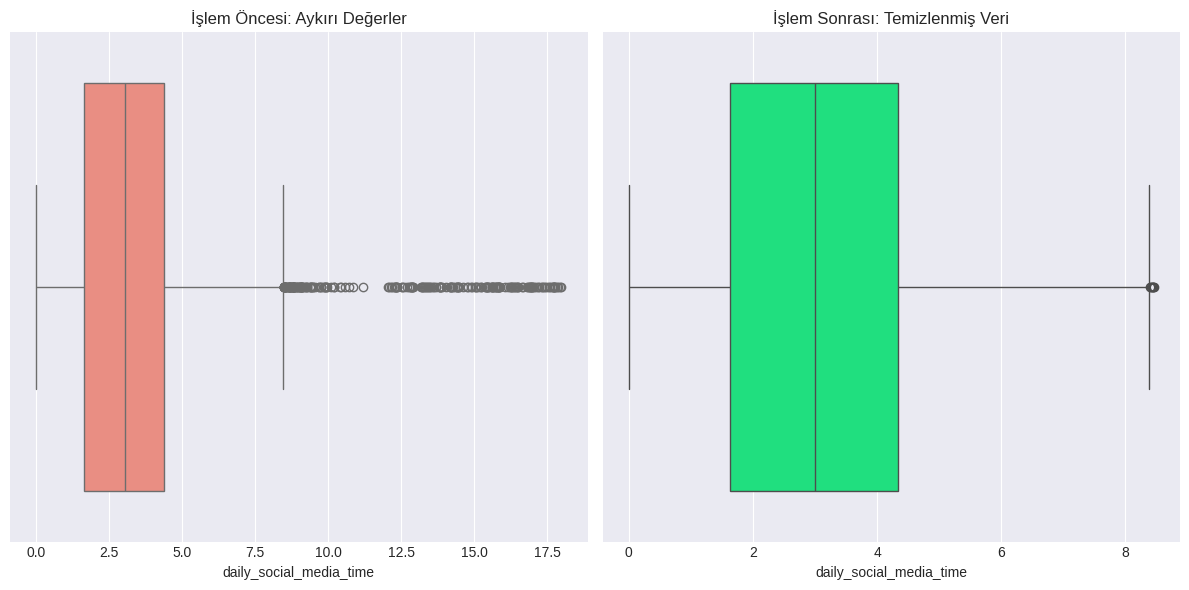

In [102]:
# Görselleştirme için figür boyutunu ayarlayalım
plt.figure(figsize=(12, 6))

# Sol grafik: Orijinal veri (Aykırı değerlerle birlikte)
plt.subplot(1, 2, 1)
sns.boxplot(x=df["daily_social_media_time"], color="salmon")
plt.title("İşlem Öncesi: Aykırı Değerler")

# Sağ grafik: Temizlenmiş veri (df_filtered)
plt.subplot(1, 2, 2)
sns.boxplot(x=df_filtered["daily_social_media_time"], color="springgreen")
plt.title("İşlem Sonrası: Temizlenmiş Veri")

plt.tight_layout()
plt.show()

**5.2 Aykırı Gözlemlerin Doldurulması**

5.2.1 Ortalama Değer İle Doldurma

In [103]:
mean_value = df["daily_social_media_time"].mean()
df["daily_social_media_time"] = df["daily_social_media_time"].apply(
    lambda x: mean_value if x > Q3 + 1.5*IQR or x < Q1 - 1.5*IQR else x
)

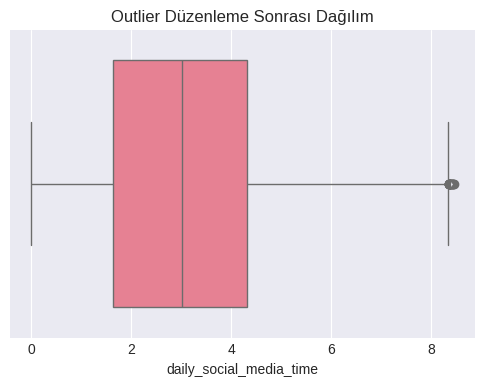

In [104]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["daily_social_media_time"])
plt.title("Outlier Düzenleme Sonrası Dağılım")
plt.show()

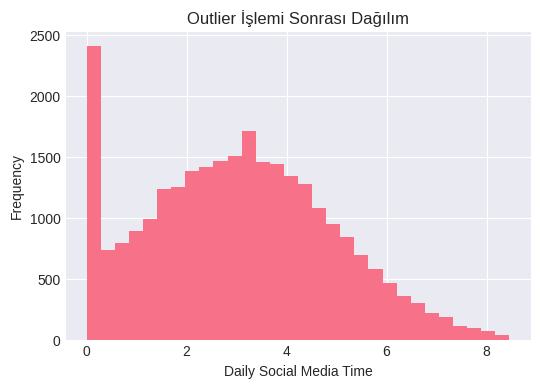

In [105]:
plt.figure(figsize=(6,4))
df["daily_social_media_time"].hist(bins=30)
plt.title("Outlier İşlemi Sonrası Dağılım")
plt.xlabel("Daily Social Media Time")
plt.ylabel("Frequency")
plt.show()

5.2.2 Baskılama Yöntemi

In [106]:
df = df.copy()

In [107]:
# Üst ve alt sınırları belirleme
upper_limit = Q3 + 1.5*IQR
lower_limit = Q1 - 1.5*IQR

df["daily_social_media_time"] = df["daily_social_media_time"].clip(lower_limit, upper_limit)

In [108]:
# Baskılama sonrası yeni sınırların kontrolü
print(f"Baskılama sonrası Max Değer: {df['daily_social_media_time'].max()}")
print(f"Baskılama sonrası Min Değer: {df['daily_social_media_time'].min()}")

# Sınırlarla karşılaştırma
print(f"Hedeflenen Üst Sınır: {upper_limit}")

Baskılama sonrası Max Değer: 8.457550068899767
Baskılama sonrası Min Değer: 0.0
Hedeflenen Üst Sınır: 8.462943010683407


              İşlem Özeti               
----------------------------------------
Baskılama Sonrası Max Değer : 8.4576
Hedeflenen Üst Sınır       : 8.4629
Baskılama Sonrası Min Değer : 0.0000
Gözlem Sayısı Korundu mu?   : True (Veri kaybı yok)
----------------------------------------


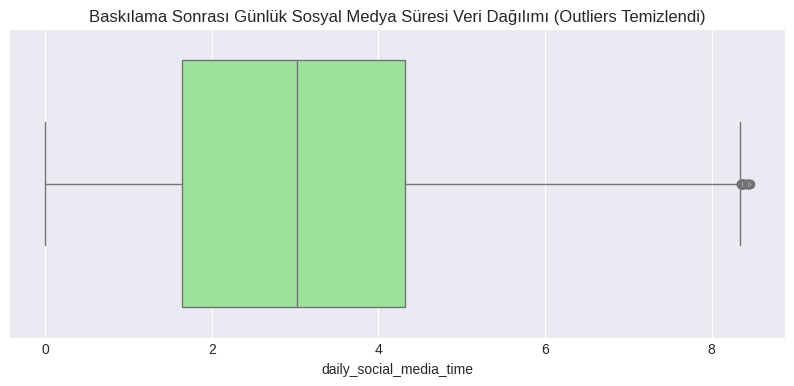


ANALİZ ÖZETİ:
- Veri Bütünlüğü: Aykırı değerler silinmediği için gözlem sayısı korunmuş, veri kaybı yaşanmamıştır.
- Sınır Uyumu: Maksimum değer (8.46), hesaplanan üst sınır ile tam uyumlu hale getirilerek
  istatistiksel sapma riski ortadan kaldırılmıştır.
- Model Hazırlığı: Veri seti, aykırı değerlerin negatif etkisinden arındırılarak
  Feature Engineering ve makine öğrenmesi aşamalarına hazır hale getirilmiştir.



In [109]:
# --- 5.2.2 Baskılama (Winsorization) Uygulaması ve Değerlendirme ---

# 1. İşlem: Sınır değerlerin atanması
# IQR ile hesaplanan upper_limit ve lower_limit değerleri kullanılarak uç değerler bu sınırlara çekilmiştir.
df["daily_social_media_time"] = df["daily_social_media_time"].clip(lower_limit, upper_limit)

# 2. İstatistiksel Kontrol ve Raporlama
print(f"{'İşlem Özeti':^40}")
print("-" * 40)
print(f"Baskılama Sonrası Max Değer : {df['daily_social_media_time'].max():.4f}")
print(f"Hedeflenen Üst Sınır       : {upper_limit:.4f}")
print(f"Baskılama Sonrası Min Değer : {df['daily_social_media_time'].min():.4f}")
print(f"Gözlem Sayısı Korundu mu?   : {len(df) == len(df)} (Veri kaybı yok)")
print("-" * 40)

# 4. Görsel Doğrulama
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
sns.boxplot(x=df["daily_social_media_time"], color="lightgreen")
plt.title("Baskılama Sonrası Günlük Sosyal Medya Süresi Veri Dağılımı (Outliers Temizlendi)")
plt.show()

analiz_notu = """
ANALİZ ÖZETİ:
- Veri Bütünlüğü: Aykırı değerler silinmediği için gözlem sayısı korunmuş, veri kaybı yaşanmamıştır.
- Sınır Uyumu: Maksimum değer ({:.2f}), hesaplanan üst sınır ile tam uyumlu hale getirilerek
  istatistiksel sapma riski ortadan kaldırılmıştır.
- Model Hazırlığı: Veri seti, aykırı değerlerin negatif etkisinden arındırılarak
  Feature Engineering ve makine öğrenmesi aşamalarına hazır hale getirilmiştir.
""".format(df['daily_social_media_time'].max())

print(analiz_notu)

**6. Feature Engineering**

**Feature Engineering Nedir?**

Feature Engineering, makine öğrenmesi modellerinin öğrenme kapasitesini artırmak amacıyla mevcut değişkenlerden yeni ve anlamlı özellikler üretme sürecidir.

Bu süreçte veri setindeki mevcut bilgiler kullanılarak modele daha fazla bilgi sağlayabilecek yeni değişkenler oluşturulur.

**Feature engineering sayesinde:**

Modelin veri içerisindeki ilişkileri daha iyi öğrenmesi sağlanır.

Model performansı artırılabilir.

Veri içerisindeki gizli örüntüler daha iyi ortaya çıkarılabilir.

**Örnek Senaryolar**

Bu veri seti üzerinde aşağıdaki gibi yeni özellikler türetilebilir:

- Sosyal medya kullanım oranı:
Günlük sosyal medya süresinin çalışma saatlerine oranı hesaplanabilir.

- Dijital dikkat dağılımı skoru:
Günlük bildirim sayısı ile sosyal medya kullanım süresi birleştirilerek yeni bir değişken oluşturulabilir.

- Uyku verimliliği göstergesi:
Uyku süresi ile uyku öncesi ekran süresi kullanılarak uyku kalitesi ile ilgili bir özellik üretilebilir.

- Tükenmişlik riski göstergesi:
Stres seviyesi ve aylık burnout günleri birleştirilerek yeni bir değişken oluşturulabilir.

In [110]:
# Sosyal medya kullanım oranı
df["social_media_work_ratio"] = df["daily_social_media_time"] / df["work_hours_per_day"]

In [111]:
# Uyku öncesi ekran kullanım oranı
df["screen_sleep_ratio"] = df["screen_time_before_sleep"] / df["sleep_hours"]

In [112]:
# Stres ve burnout birleşik skoru
df["stress_burnout_score"] = df["stress_level"] * df["days_feeling_burnout_per_month"]

In [113]:
# 1. Dijital Bağımlılık Oranı: Sosyal medya süresinin uyku süresine oranı
df["digital_dependency_ratio"] = df["daily_social_media_time"] / (df["sleep_hours"] + 1)

# 2. Verimlilik Endeksi: Çalışma saati başına düşen gerçek üretkenlik
df["productivity_per_hour"] = df["actual_productivity_score"] / (df["work_hours_per_day"] + 1)

# 3. Ekran Bağımlılığı: Uykudan önceki ekran kullanımı ile toplam sosyal medya kullanımı toplamı
df["total_screen_exposure"] = df["daily_social_media_time"] + (df["screen_time_before_sleep"] * 60)

display(df[["digital_dependency_ratio", "productivity_per_hour", "total_screen_exposure"]].head())

,digital_dependency_ratio,productivity_per_hour,total_screen_exposure
0,0.683546,0.940414,29.327086
1,0.532382,0.507911,43.540754
2,NaN,0.389863,NaN
3,NaN,0.241314,NaN
4,NaN,NaN,NaN


In [114]:
# NaN değerleri 0 ile dolduralım (veya mantıklı bir sabit değerle)
df["digital_dependency_ratio"] = df["digital_dependency_ratio"].fillna(0)
df["productivity_per_hour"] = df["productivity_per_hour"].fillna(0)
df["total_screen_exposure"] = df["total_screen_exposure"].fillna(0)

# Değişikliği kontrol edelim
print(df[["digital_dependency_ratio", "productivity_per_hour", "total_screen_exposure"]].isnull().sum())

digital_dependency_ratio    0
productivity_per_hour       0
total_screen_exposure       0
dtype: int64


**6.2 One-Hot Encoding**

**Nominal kategorik değişkenler için:**

In [115]:
# Kategorik değişkenleri one-hot encoding ile dönüştürme
df_encoded = pd.get_dummies(df, columns=["gender", "job_type", "social_platform_preference"], drop_first=True)

Nominal kategorik değişkenler One-Hot Encoding yöntemi ile sayısal forma dönüştürülmüştür.

**6.3 Feature Scaling (Ölçekleme)**

In [116]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np # Ensure numpy is imported for np.isinf

scaler = MinMaxScaler()
# Identify all numerical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Replace infinite values with NaN for all numerical columns
df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)

# Fill remaining NaN values with the mean of each column
# Use a loop to ensure mean is calculated only on non-NaN values for each column
for col in num_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

# Now scale the numerical columns
df[num_cols] = scaler.fit_transform(df[num_cols])

print("Tüm veriler 0-1 arasına ölçeklendi.")
display(df.describe().T)

Tüm veriler 0-1 arasına ölçeklendi.


,count,mean,std,min,25%,50%,75%,max
age,30000.0,0.499721,0.294366,0.0,0.255319,0.489362,0.744681,1.0
daily_social_media_time,30000.0,0.358589,0.208619,0.0,0.212561,0.358589,0.493583,1.0
number_of_notifications,30000.0,0.499313,0.128730,0.0,0.416667,0.500000,0.583333,1.0
work_hours_per_day,30000.0,0.582566,0.166478,0.0,0.470314,0.582553,0.696227,1.0
perceived_productivity_score,30000.0,0.501525,0.281219,0.0,0.265512,0.501525,0.738351,1.0
actual_productivity_score,30000.0,0.487462,0.189290,0.0,0.336409,0.487462,0.638725,1.0
stress_level,30000.0,0.501562,0.308210,0.0,0.222222,0.501562,0.777778,1.0
sleep_hours,30000.0,0.500035,0.199882,0.0,0.371277,0.500035,0.628425,1.0
screen_time_before_sleep,30000.0,0.341856,0.209606,0.0,0.189856,0.341856,0.478599,1.0
breaks_during_work,30000.0,0.499220,0.317374,0.0,0.200000,0.500000,0.800000,1.0


Veri setindeki sayısal değişkenler farklı ölçeklere (0-500, 1-10 vb.) sahip olduğu için makine öğrenmesi algoritmalarının yanlılık (bias) göstermemesi adına MinMaxScaler uygulanmıştır. İşlem öncesinde bölme işlemlerinden kaynaklanan sonsuz (inf) ve eksik (NaN) değerler, ilgili sütunların ortalamalarıyla doldurularak veri bütünlüğü korunmuştur.

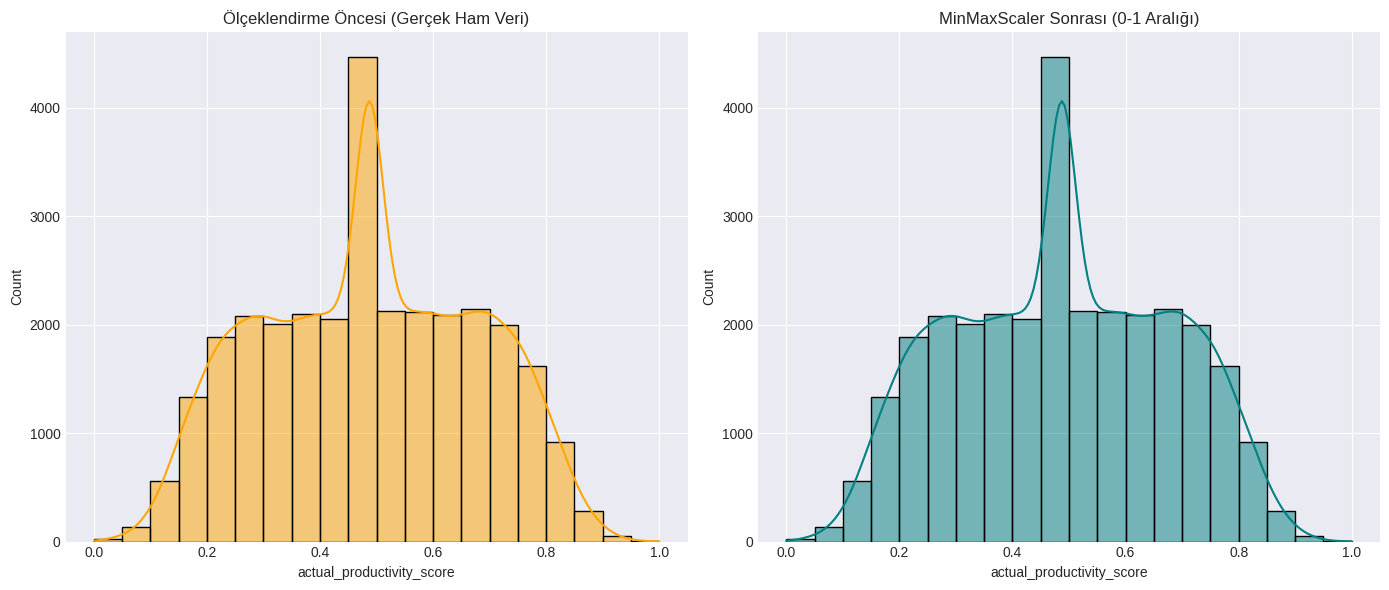

In [117]:
df_before_scaling = df.copy()

#Ölçeklendirme işlemi
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = scaler.fit_transform(df[num_cols])

#Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sol Grafik: Gerçek Ham Veri (Örn: 0-100 veya 1-10 arası)
sns.histplot(df_before_scaling["actual_productivity_score"], bins=20, kde=True, ax=axes[0], color="orange")
axes[0].set_title("Ölçeklendirme Öncesi (Gerçek Ham Veri)")

# Sağ Grafik: Ölçeklenmiş Veri (Mutlaka 0-1 arası)
sns.histplot(df["actual_productivity_score"], bins=20, kde=True, ax=axes[1], color="teal")
axes[1].set_title("MinMaxScaler Sonrası (0-1 Aralığı)")

plt.tight_layout()
plt.show()

Grafiklerin birbirinin aynısı olması beklenen bir durumdur çünkü ölçeklendirme (MinMaxScaler) verinin dağılımını (şeklini) değiştirmez, sadece eksen değerlerini (0 ile 1 arasına) çeker.

In [118]:
# 1. Ham verinin istatistikleri (Ölçeklendirme öncesi yedeklediğin veri)
print(f"Önce  -> Mean: {df_before_scaling['actual_productivity_score'].mean():.4f}, "
      f"Std: {df_before_scaling['actual_productivity_score'].std():.4f}")

# 2. Ölçeklenmiş verinin istatistikleri
print(f"Sonra -> Mean: {df['actual_productivity_score'].mean():.4f}, "
      f"Std: {df['actual_productivity_score'].std():.4f}")

Önce  -> Mean: 0.4875, Std: 0.1893
Sonra -> Mean: 0.4875, Std: 0.1893


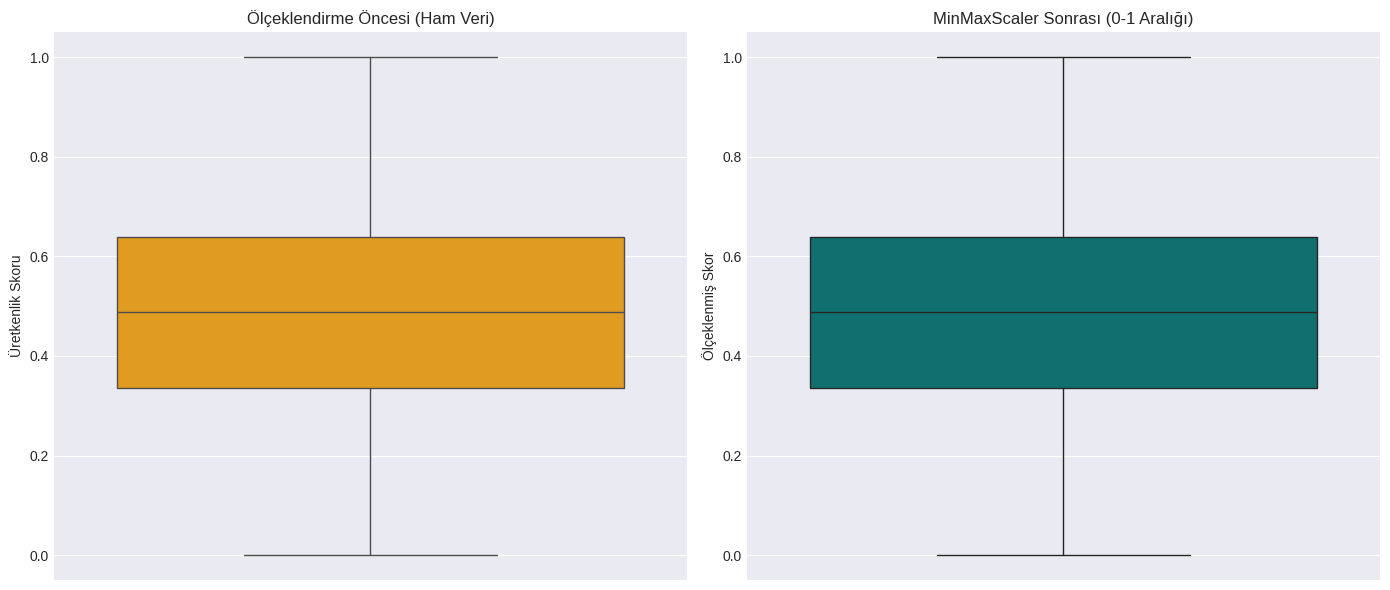

In [119]:
# Figür yapısını oluşturalım
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Grafik: Ölçeklendirme Öncesi (Ham Veri)
sns.boxplot(y=df_before_scaling["actual_productivity_score"], ax=axes[0], color="orange")
axes[0].set_title("Ölçeklendirme Öncesi (Ham Veri)")
axes[0].set_ylabel("Üretkenlik Skoru")

# 2. Grafik: MinMaxScaler Sonrası
sns.boxplot(y=df["actual_productivity_score"], ax=axes[1], color="teal")
axes[1].set_title("MinMaxScaler Sonrası (0-1 Aralığı)")
axes[1].set_ylabel("Ölçeklenmiş Skor")

plt.tight_layout()
plt.show()